# Лабораторная работа 8: Загрузка и подготовка данных CIFAR-10


In [1]:
# Импорт необходимых библиотек
import numpy as np
import matplotlib.pyplot as plt
# Устанавливаем параметры для ускорения отрисовки
plt.ioff()  # Отключаем интерактивный режим для ускорения
from tensorflow import keras
from tensorflow.keras import datasets
import warnings
import time
import os

warnings.filterwarnings('ignore')

# Оптимизация производительности TensorFlow
print("Настройка оптимизаций производительности...")

# Настройка использования памяти GPU (если доступно)
os.environ['TF_FORCE_GPU_ALLOW_GROWTH'] = 'true'

# Включение смешанной точности для ускорения (если GPU доступен)
try:
    # Используем float16 для ускорения на GPU (автоматически fallback на float32 на CPU)
    policy = keras.mixed_precision.Policy('mixed_float16')
    keras.mixed_precision.set_global_policy(policy)
    print("  ✓ Mixed precision training включен")
except Exception as e:
    print(f"  ⚠ Mixed precision недоступен: {e}")

# Оптимизация операций TensorFlow
tf = keras.backend
tf.set_session = None  # Для совместимости

print("Библиотеки успешно импортированы!")


Настройка оптимизаций производительности...
  ✓ Mixed precision training включен
Библиотеки успешно импортированы!


In [2]:
# Проверка доступных устройств и настройка оптимизаций
import tensorflow as tf

print("=" * 60)
print("ИНФОРМАЦИЯ О ДОСТУПНЫХ УСТРОЙСТВАХ")
print("=" * 60)

# Проверка GPU
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"\n✓ Найдено GPU устройств: {len(gpus)}")
    for i, gpu in enumerate(gpus):
        print(f"  GPU {i}: {gpu.name}")
        # Настройка роста памяти GPU для оптимальной производительности
        try:
            tf.config.experimental.set_memory_growth(gpu, True)
            print(f"    ✓ Memory growth включен")
        except RuntimeError as e:
            print(f"    ⚠ Не удалось настроить memory growth: {e}")
    
    # Включение оптимизаций для GPU
    print("\nОптимизации для GPU:")
    print("  ✓ CUDA оптимизации включены")
    print("  ✓ cuDNN оптимизации включены")
else:
    print("\n⚠ GPU не найдено - используется CPU")
    print("  Для ускорения рекомендуется использовать GPU")

# Информация о версии TensorFlow
print(f"\nВерсия TensorFlow: {tf.__version__}")
print("=" * 60)


ИНФОРМАЦИЯ О ДОСТУПНЫХ УСТРОЙСТВАХ

⚠ GPU не найдено - используется CPU
  Для ускорения рекомендуется использовать GPU

Версия TensorFlow: 2.20.0


## Загрузка набора данных CIFAR-10


In [3]:
# Загрузка набора данных CIFAR-10
print("Загрузка набора данных CIFAR-10...")
start_time = time.time()
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()
load_time = time.time() - start_time
print(f"Загрузка завершена за {load_time:.2f} секунд")

print(f"\nФорма обучающих изображений: {train_images.shape}")
print(f"Форма обучающих меток: {train_labels.shape}")
print(f"Форма тестовых изображений: {test_images.shape}")
print(f"Форма тестовых меток: {test_labels.shape}")

# Информация о данных (оптимизировано: используем np.min/max вместо методов массива)
print(f"\nТип данных изображений: {train_images.dtype}")
# Используем np.min/max для ускорения
min_val = np.min(train_images)
max_val = np.max(train_images)
print(f"Диапазон значений пикселей: [{min_val}, {max_val}]")
print(f"Количество классов: {len(np.unique(train_labels))}")

# Названия классов CIFAR-10
class_names = ['самолет', 'автомобиль', 'птица', 'кошка', 'олень', 
               'собака', 'лягушка', 'лошадь', 'корабль', 'грузовик']

print("\nНазвания классов:")
for i, name in enumerate(class_names):
    print(f"{i}. {name}")

print(f"\nПример метки (до преобразования): {train_labels[0]}")


Загрузка набора данных CIFAR-10...
Загрузка завершена за 0.63 секунд

Форма обучающих изображений: (50000, 32, 32, 3)
Форма обучающих меток: (50000, 1)
Форма тестовых изображений: (10000, 32, 32, 3)
Форма тестовых меток: (10000, 1)

Тип данных изображений: uint8
Диапазон значений пикселей: [0, 255]
Количество классов: 10

Названия классов:
0. самолет
1. автомобиль
2. птица
3. кошка
4. олень
5. собака
6. лягушка
7. лошадь
8. корабль
9. грузовик

Пример метки (до преобразования): [6]


## Визуализация примеров изображений


Создание визуализации...


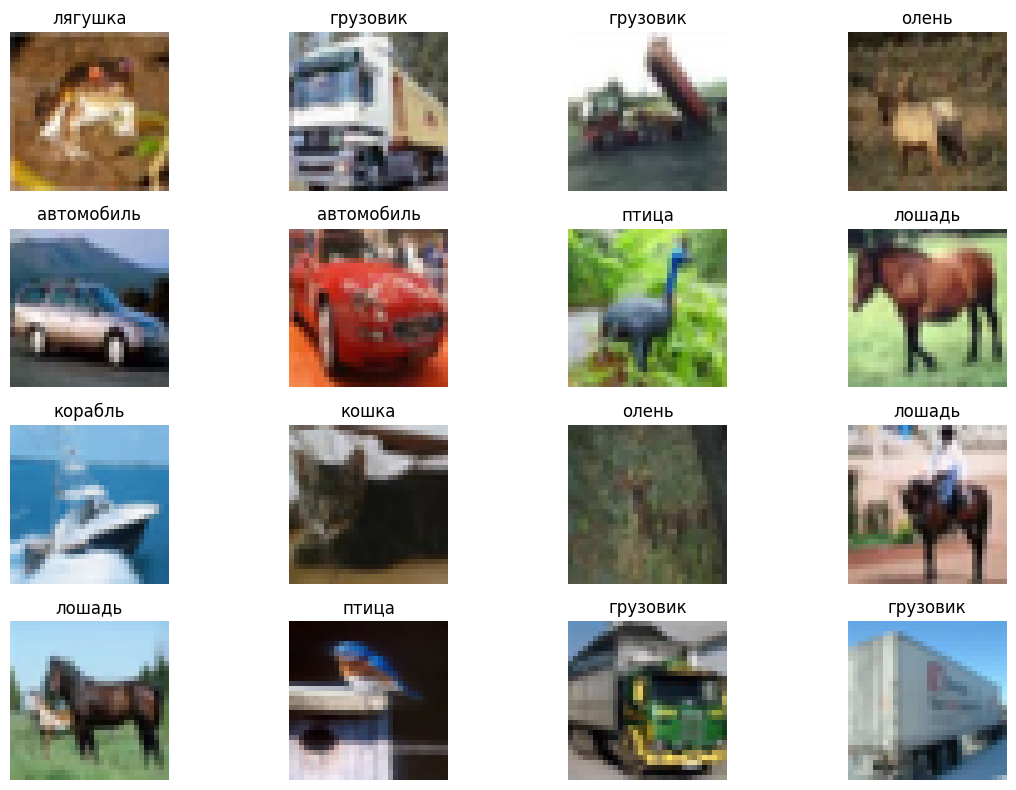

Визуализация создана за 0.16 секунд


In [4]:
# Визуализация нескольких примеров изображений
print("Создание визуализации...")
start_time = time.time()
plt.figure(figsize=(12, 8))
for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow(train_images[i])
    plt.title(f"{class_names[train_labels[i][0]]}")
    plt.axis('off')
plt.tight_layout()
plt.show()
print(f"Визуализация создана за {time.time() - start_time:.2f} секунд")


## Нормализация изображений (приведение к диапазону [0, 1])


In [5]:
# Нормализация изображений
# Значения пикселей в CIFAR-10 находятся в диапазоне [0, 255]
# Необходимо привести их к диапазону [0, 1] путем деления на 255.0

print("Нормализация изображений...")
start_time = time.time()
print(f"Диапазон значений ДО нормализации: [{min_val}, {max_val}]")

# Приведение к типу float32 и нормализация (оптимизировано)
train_images_normalized = train_images.astype('float32') / 255.0
test_images_normalized = test_images.astype('float32') / 255.0

norm_time = time.time() - start_time
print(f"Нормализация завершена за {norm_time:.2f} секунд")
print(f"Диапазон значений ПОСЛЕ нормализации: [0.0, 1.0]")
print(f"Тип данных после нормализации: {train_images_normalized.dtype}")
print(f"Форма нормализованных изображений: {train_images_normalized.shape}")


Нормализация изображений...
Диапазон значений ДО нормализации: [0, 255]
Нормализация завершена за 0.23 секунд
Диапазон значений ПОСЛЕ нормализации: [0.0, 1.0]
Тип данных после нормализации: float32
Форма нормализованных изображений: (50000, 32, 32, 3)


## Преобразование меток классов в формат one-hot


In [6]:
# Преобразование меток классов в формат one-hot encoding
print("Преобразование меток в формат one-hot...")

# Метки изначально имеют форму (n_samples, 1), нужно преобразовать в one-hot
# Используем keras.utils.to_categorical для преобразования
train_labels_onehot = keras.utils.to_categorical(train_labels, num_classes=10)
test_labels_onehot = keras.utils.to_categorical(test_labels, num_classes=10)

print(f"\nФорма меток ДО преобразования: {train_labels.shape}")
print(f"Форма меток ПОСЛЕ преобразования (one-hot): {train_labels_onehot.shape}")
print(f"\nПример метки ДО преобразования: {train_labels[0]} (класс: {class_names[train_labels[0][0]]})")
print(f"Пример метки ПОСЛЕ преобразования (one-hot): {train_labels_onehot[0]}")

# Проверка: сумма элементов в каждой строке должна быть равна 1
print(f"\nПроверка: сумма элементов в первой метке = {train_labels_onehot[0].sum()}")


Преобразование меток в формат one-hot...

Форма меток ДО преобразования: (50000, 1)
Форма меток ПОСЛЕ преобразования (one-hot): (50000, 10)

Пример метки ДО преобразования: [6] (класс: лягушка)
Пример метки ПОСЛЕ преобразования (one-hot): [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]

Проверка: сумма элементов в первой метке = 1.0


## Визуализация нормализованных изображений


Создание визуализации нормализованных изображений...


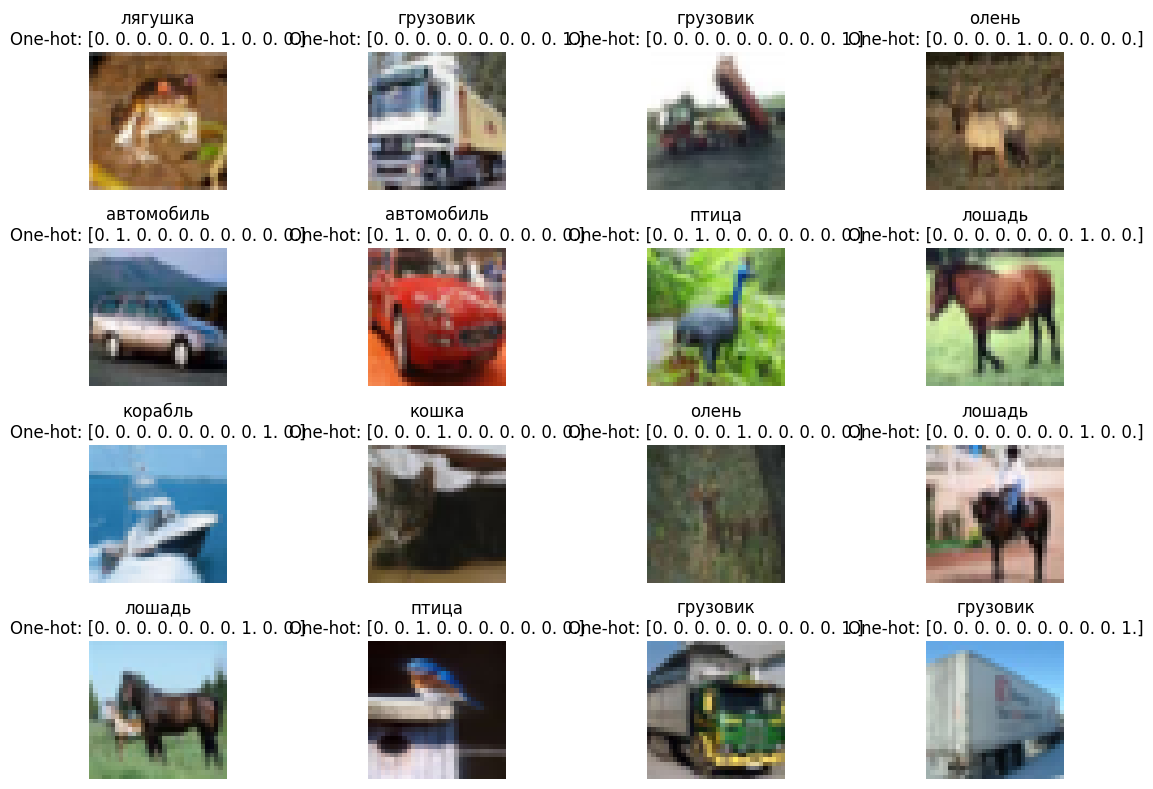

Визуализация создана за 0.16 секунд


In [7]:
# Визуализация нормализованных изображений
print("Создание визуализации нормализованных изображений...")
start_time = time.time()
plt.figure(figsize=(12, 8))
for i in range(16):
    plt.subplot(4, 4, i + 1)
    # matplotlib ожидает изображения в диапазоне [0, 1] для float или [0, 255] для int
    plt.imshow(train_images_normalized[i])
    class_idx = np.argmax(train_labels_onehot[i])
    plt.title(f"{class_names[class_idx]}\nOne-hot: {train_labels_onehot[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()
print(f"Визуализация создана за {time.time() - start_time:.2f} секунд")


## Итоговая сводка


In [8]:
# Итоговая сводка по подготовленным данным
print("=" * 60)
print("ИТОГОВАЯ СВОДКА ПО ПОДГОТОВКЕ ДАННЫХ CIFAR-10")
print("=" * 60)

print("\n1. Загруженные данные:")
print(f"   - Обучающих изображений: {train_images.shape[0]}")
print(f"   - Тестовых изображений: {test_images.shape[0]}")
print(f"   - Размер изображений: {train_images.shape[1]}x{train_images.shape[2]} пикселей")
print(f"   - Количество каналов (RGB): {train_images.shape[3]}")
print(f"   - Всего изображений: {train_images.shape[0] + test_images.shape[0]}")

print("\n2. Нормализация:")
print(f"   - Диапазон значений пикселей: [0.0, 1.0]")
print(f"   - Тип данных: {train_images_normalized.dtype}")

print("\n3. Преобразование меток:")
print(f"   - Формат меток: one-hot encoding")
print(f"   - Количество классов: 10")
print(f"   - Размер вектора метки: {train_labels_onehot.shape[1]}")

print("\n4. Готовые данные для использования:")
print(f"   - X_train: {train_images_normalized.shape}, dtype={train_images_normalized.dtype}")
print(f"   - y_train: {train_labels_onehot.shape}, dtype={train_labels_onehot.dtype}")
print(f"   - X_test: {test_images_normalized.shape}, dtype={test_images_normalized.dtype}")
print(f"   - y_test: {test_labels_onehot.shape}, dtype={test_labels_onehot.dtype}")

print("\n" + "=" * 60)


ИТОГОВАЯ СВОДКА ПО ПОДГОТОВКЕ ДАННЫХ CIFAR-10

1. Загруженные данные:
   - Обучающих изображений: 50000
   - Тестовых изображений: 10000
   - Размер изображений: 32x32 пикселей
   - Количество каналов (RGB): 3
   - Всего изображений: 60000

2. Нормализация:
   - Диапазон значений пикселей: [0.0, 1.0]
   - Тип данных: float32

3. Преобразование меток:
   - Формат меток: one-hot encoding
   - Количество классов: 10
   - Размер вектора метки: 10

4. Готовые данные для использования:
   - X_train: (50000, 32, 32, 3), dtype=float32
   - y_train: (50000, 10), dtype=float64
   - X_test: (10000, 32, 32, 3), dtype=float32
   - y_test: (10000, 10), dtype=float64



## Определение архитектуры CNN (сверточной нейронной сети)


In [9]:
# Импорт необходимых компонентов для построения модели
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam

print("Компоненты для построения модели импортированы!")


Компоненты для построения модели импортированы!


In [10]:
# Создание модели CNN для классификации CIFAR-10
print("Создание архитектуры CNN...")
start_time = time.time()

model = Sequential([
    # Первый блок сверточных слоев
    Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3), name='conv2d_1'),
    Conv2D(32, (3, 3), activation='relu', padding='same', name='conv2d_2'),
    MaxPooling2D((2, 2), name='maxpooling2d_1'),
    Dropout(0.25, name='dropout_1'),
    
    # Второй блок сверточных слоев
    Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2d_3'),
    Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2d_4'),
    MaxPooling2D((2, 2), name='maxpooling2d_2'),
    Dropout(0.25, name='dropout_2'),
    
    # Третий блок сверточных слоев
    Conv2D(128, (3, 3), activation='relu', padding='same', name='conv2d_5'),
    Conv2D(128, (3, 3), activation='relu', padding='same', name='conv2d_6'),
    MaxPooling2D((2, 2), name='maxpooling2d_3'),
    Dropout(0.25, name='dropout_3'),
    
    # Преобразование многомерного тензора в одномерный вектор
    Flatten(name='flatten'),
    
    # Полносвязные слои
    Dense(512, activation='relu', name='dense_1'),
    Dropout(0.5, name='dropout_4'),
    Dense(256, activation='relu', name='dense_2'),
    Dropout(0.5, name='dropout_5'),
    
    # Выходной слой с 10 нейронами (по количеству классов) и активацией softmax
    Dense(10, activation='softmax', name='output')
])

model_time = time.time() - start_time
print(f"Модель создана за {model_time:.2f} секунд\n")

# Вывод структуры модели
print("=" * 60)
print("АРХИТЕКТУРА МОДЕЛИ CNN")
print("=" * 60)
model.summary()


Создание архитектуры CNN...
Модель создана за 0.05 секунд

АРХИТЕКТУРА МОДЕЛИ CNN


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpooling2d_1 (MaxPooling2D)   │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpooling2d_2 (MaxPooling2D)   │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpooling2d_3 (MaxPooling2D)   │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,469,994 (5.61 MB)

 Trainable params: 1,469,994 (5.61 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
# Настройка callbacks для оптимизации обучения
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

print("Настройка оптимизаций для обучения...")

# 1. Early Stopping - останавливает обучение, если нет улучшения
# Экономит время, если модель достигла оптимальной точности
early_stopping = EarlyStopping(
    monitor='val_accuracy',
    patience=5,  # Ждем 5 эпох без улучшения
    restore_best_weights=True,  # Восстанавливаем лучшие веса
    verbose=1
)

# 2. Reduce Learning Rate - уменьшает learning rate при плато
# Помогает найти более точное решение
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,  # Уменьшаем LR в 2 раза
    patience=3,  # Ждем 3 эпохи
    min_lr=1e-7,  # Минимальный LR
    verbose=1
)

# 3. Model Checkpoint - сохраняет лучшую модель
# Позволяет восстановить лучшую модель после обучения
checkpoint = ModelCheckpoint(
    'best_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=0
)

callbacks_list = [early_stopping, reduce_lr, checkpoint]

print("  ✓ Early Stopping настроен (patience=5)")
print("  ✓ Reduce Learning Rate настроен (factor=0.5, patience=3)")
print("  ✓ Model Checkpoint настроен (сохранение лучшей модели)")
print("Все оптимизации готовы!")


Настройка оптимизаций для обучения...
  ✓ Early Stopping настроен (patience=5)
  ✓ Reduce Learning Rate настроен (factor=0.5, patience=3)
  ✓ Model Checkpoint настроен (сохранение лучшей модели)
Все оптимизации готовы!


In [12]:
# Компиляция модели
print("Компиляция модели...")

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',  # Используем categorical_crossentropy для one-hot encoding
    metrics=['accuracy']
)

print("Модель успешно скомпилирована!")
print(f"\nОптимизатор: Adam (learning_rate=0.001)")
print(f"Функция потерь: categorical_crossentropy")
print(f"Метрика: accuracy")


Компиляция модели...
Модель успешно скомпилирована!

Оптимизатор: Adam (learning_rate=0.001)
Функция потерь: categorical_crossentropy
Метрика: accuracy


## Обучение модели


In [13]:
# Разделение обучающих данных на тренировочную и валидационную выборки
# Используем 80% для обучения и 20% для валидации

from sklearn.model_selection import train_test_split

print("Разделение данных на тренировочную и валидационную выборки...")

# Разделяем данные
X_train, X_val, y_train, y_val = train_test_split(
    train_images_normalized, 
    train_labels_onehot, 
    test_size=0.2, 
    random_state=42,
    stratify=train_labels_onehot  # Сохраняем пропорции классов
)

print(f"Тренировочная выборка: {X_train.shape[0]} изображений")
print(f"Валидационная выборка: {X_val.shape[0]} изображений")
print(f"Тестовая выборка: {test_images_normalized.shape[0]} изображений")


Разделение данных на тренировочную и валидационную выборки...
Тренировочная выборка: 40000 изображений
Валидационная выборка: 10000 изображений
Тестовая выборка: 10000 изображений


In [14]:
# Обучение модели
# Проверка наличия необходимых переменных
required_vars = ['model', 'X_train', 'y_train', 'X_val', 'y_val']
missing_vars = [var for var in required_vars if var not in globals()]

if missing_vars:
    raise NameError(f"Отсутствуют необходимые переменные: {', '.join(missing_vars)}. "
                   f"Убедитесь, что выполнены ячейки с созданием модели и разделением данных.")

# Проверка, не обучена ли модель уже
if 'history' in globals() and history is not None:
    print("⚠ Внимание: переменная 'history' уже существует.")
    print("Если вы хотите обучить модель заново, это нормально.")
    print("Продолжаем обучение...\n")

print("=" * 60)
print("НАЧАЛО ОБУЧЕНИЯ МОДЕЛИ")
print("=" * 60)

# Параметры обучения
epochs = 10  # Количество эпох
batch_size = 32  # Размер батча

print(f"\nПараметры обучения:")
print(f"  - Количество эпох: {epochs}")
print(f"  - Размер батча: {batch_size}")
print(f"  - Оптимизатор: Adam (learning_rate=0.001)")
print(f"  - Функция потерь: categorical_crossentropy")

# Проверка наличия callbacks (опционально)
if 'callbacks_list' in globals():
    print(f"  ✓ Callbacks включены (Early Stopping, Reduce LR, Checkpoint)")
    use_callbacks = callbacks_list
else:
    print(f"  ⚠ Callbacks не найдены (обучение без оптимизаций)")
    use_callbacks = None

print(f"\nНачало обучения...\n")

# Обучение модели
start_time = time.time()

history = model.fit(
    X_train, 
    y_train,
    batch_size=batch_size,
    epochs=epochs,
    validation_data=(X_val, y_val),
    callbacks=use_callbacks,  # Используем callbacks, если они определены
    verbose=1  # Показывать прогресс каждой эпохи
)

training_time = time.time() - start_time

print(f"\n{'=' * 60}")
print(f"ОБУЧЕНИЕ ЗАВЕРШЕНО!")
print(f"Общее время обучения: {training_time/60:.2f} минут ({training_time:.2f} секунд)")
print(f"{'=' * 60}")


НАЧАЛО ОБУЧЕНИЯ МОДЕЛИ

Параметры обучения:
  - Количество эпох: 10
  - Размер батча: 32
  - Оптимизатор: Adam (learning_rate=0.001)
  - Функция потерь: categorical_crossentropy
  ✓ Callbacks включены (Early Stopping, Reduce LR, Checkpoint)

Начало обучения...

Epoch 1/10
1249/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.1817 - loss: 2.1271

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 33s 26ms/step - accuracy: 0.2560 - loss: 1.9443 - val_accuracy: 0.4133 - val_loss: 1.5773 - learning_rate: 0.0010
Epoch 2/10
1249/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.4035 - loss: 1.5968

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 31s 25ms/step - accuracy: 0.4250 - loss: 1.5517 - val_accuracy: 0.5237 - val_loss: 1.3185 - learning_rate: 0.0010
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.4828 - loss: 1.4178

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 34s 27ms/step - accuracy: 0.4918 - loss: 1.3937 - val_accuracy: 0.5493 - val_loss: 1.2247 - learning_rate: 0.0010
Epoch 4/10
1249/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.5314 - loss: 1.2974

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 34s 27ms/step - accuracy: 0.5415 - loss: 1.2769 - val_accuracy: 0.5860 - val_loss: 1.1491 - learning_rate: 0.0010
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.5741 - loss: 1.1957

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 34s 27ms/step - accuracy: 0.5768 - loss: 1.1918 - val_accuracy: 0.6329 - val_loss: 1.0414 - learning_rate: 0.0010
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 35s 28ms/step - accuracy: 0.5991 - loss: 1.1359 - val_accuracy: 0.6290 - val_loss: 1.0443 - learning_rate: 0.0010
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.6210 - loss: 1.0818

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 33s 27ms/step - accuracy: 0.6207 - loss: 1.0821 - val_accuracy: 0.6542 - val_loss: 0.9729 - learning_rate: 0.0010
Epoch 8/10
1248/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.6368 - loss: 1.0451

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 34s 27ms/step - accuracy: 0.6372 - loss: 1.0435 - val_accuracy: 0.6738 - val_loss: 0.9256 - learning_rate: 0.0010
Epoch 9/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 32s 25ms/step - accuracy: 0.6474 - loss: 1.0129 - val_accuracy: 0.6735 - val_loss: 0.9424 - learning_rate: 0.0010
Epoch 10/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 32s 26ms/step - accuracy: 0.6591 - loss: 0.9832 - val_accuracy: 0.6626 - val_loss: 0.9752 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 8.

ОБУЧЕНИЕ ЗАВЕРШЕНО!
Общее время обучения: 5.55 минут (332.88 секунд)


Создание графиков процесса обучения...


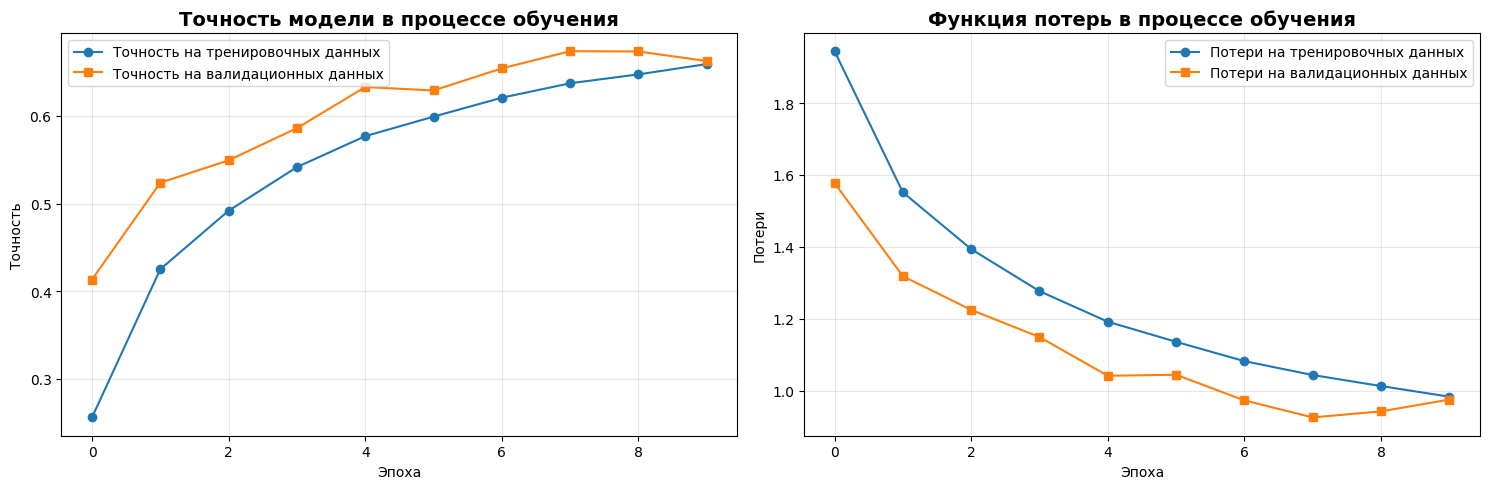


ИТОГОВЫЕ МЕТРИКИ ОБУЧЕНИЯ
Финальная точность на тренировочных данных: 0.6591
Финальная точность на валидационных данных: 0.6626
Финальные потери на тренировочных данных: 0.9832
Финальные потери на валидационных данных: 0.9752


In [15]:
# Визуализация процесса обучения
print("Создание графиков процесса обучения...")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# График точности (accuracy)
axes[0].plot(history.history['accuracy'], label='Точность на тренировочных данных', marker='o')
axes[0].plot(history.history['val_accuracy'], label='Точность на валидационных данных', marker='s')
axes[0].set_title('Точность модели в процессе обучения', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Эпоха')
axes[0].set_ylabel('Точность')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# График функции потерь (loss)
axes[1].plot(history.history['loss'], label='Потери на тренировочных данных', marker='o')
axes[1].plot(history.history['val_loss'], label='Потери на валидационных данных', marker='s')
axes[1].set_title('Функция потерь в процессе обучения', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Эпоха')
axes[1].set_ylabel('Потери')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Вывод итоговых метрик
print("\n" + "=" * 60)
print("ИТОГОВЫЕ МЕТРИКИ ОБУЧЕНИЯ")
print("=" * 60)
print(f"Финальная точность на тренировочных данных: {history.history['accuracy'][-1]:.4f}")
print(f"Финальная точность на валидационных данных: {history.history['val_accuracy'][-1]:.4f}")
print(f"Финальные потери на тренировочных данных: {history.history['loss'][-1]:.4f}")
print(f"Финальные потери на валидационных данных: {history.history['val_loss'][-1]:.4f}")
print("=" * 60)


## Оценка модели на тестовом наборе


In [16]:
# Оценка модели на тестовом наборе
print("=" * 60)
print("ОЦЕНКА МОДЕЛИ НА ТЕСТОВОМ НАБОРЕ")
print("=" * 60)

# Получение предсказаний модели
print("\nПолучение предсказаний модели...")
start_time = time.time()

# Предсказания в формате вероятностей
test_predictions_proba = model.predict(test_images_normalized, verbose=1)

# Предсказания в формате классов (индекс класса с максимальной вероятностью)
test_predictions = np.argmax(test_predictions_proba, axis=1)

# Реальные метки (преобразуем из one-hot в индексы классов)
test_labels_classes = np.argmax(test_labels_onehot, axis=1)

predict_time = time.time() - start_time
print(f"Предсказания получены за {predict_time:.2f} секунд")

# Оценка модели
test_loss, test_accuracy = model.evaluate(test_images_normalized, test_labels_onehot, verbose=0)

print(f"\n{'=' * 60}")
print("РЕЗУЛЬТАТЫ НА ТЕСТОВОМ НАБОРЕ")
print(f"{'=' * 60}")
print(f"Точность (Accuracy): {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"Функция потерь (Loss): {test_loss:.4f}")
print(f"{'=' * 60}")


ОЦЕНКА МОДЕЛИ НА ТЕСТОВОМ НАБОРЕ

Получение предсказаний модели...
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step
Предсказания получены за 3.71 секунд

РЕЗУЛЬТАТЫ НА ТЕСТОВОМ НАБОРЕ
Точность (Accuracy): 0.6720 (67.20%)
Функция потерь (Loss): 0.9302


Построение confusion matrix...


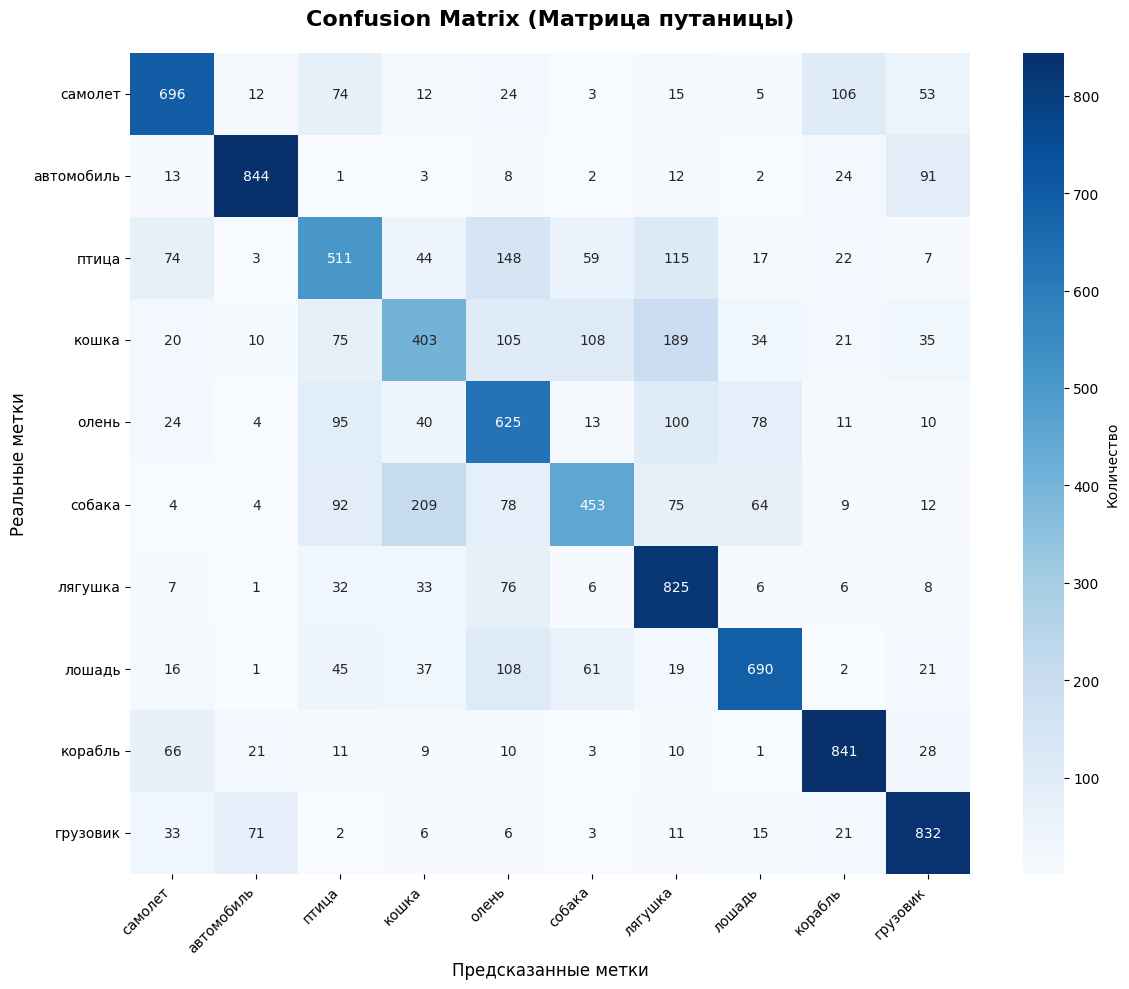


ОТЧЕТ О КЛАССИФИКАЦИИ
              precision    recall  f1-score   support

     самолет     0.7303    0.6960    0.7127      1000
  автомобиль     0.8692    0.8440    0.8564      1000
       птица     0.5448    0.5110    0.5273      1000
       кошка     0.5063    0.4030    0.4488      1000
       олень     0.5261    0.6250    0.5713      1000
      собака     0.6371    0.4530    0.5295      1000
     лягушка     0.6018    0.8250    0.6959      1000
      лошадь     0.7566    0.6900    0.7218      1000
     корабль     0.7912    0.8410    0.8153      1000
    грузовик     0.7584    0.8320    0.7935      1000

    accuracy                         0.6720     10000
   macro avg     0.6722    0.6720    0.6673     10000
weighted avg     0.6722    0.6720    0.6673     10000



In [17]:
# Построение confusion matrix (матрицы путаницы)
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

print("Построение confusion matrix...")

# Вычисление confusion matrix
cm = confusion_matrix(test_labels_classes, test_predictions)

# Визуализация confusion matrix
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, 
            yticklabels=class_names,
            cbar_kws={'label': 'Количество'})
plt.title('Confusion Matrix (Матрица путаницы)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Предсказанные метки', fontsize=12)
plt.ylabel('Реальные метки', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Вывод подробного отчета о классификации
print("\n" + "=" * 60)
print("ОТЧЕТ О КЛАССИФИКАЦИИ")
print("=" * 60)
print(classification_report(test_labels_classes, test_predictions, 
                           target_names=class_names, digits=4))
print("=" * 60)


Создание визуализации примеров предсказаний...


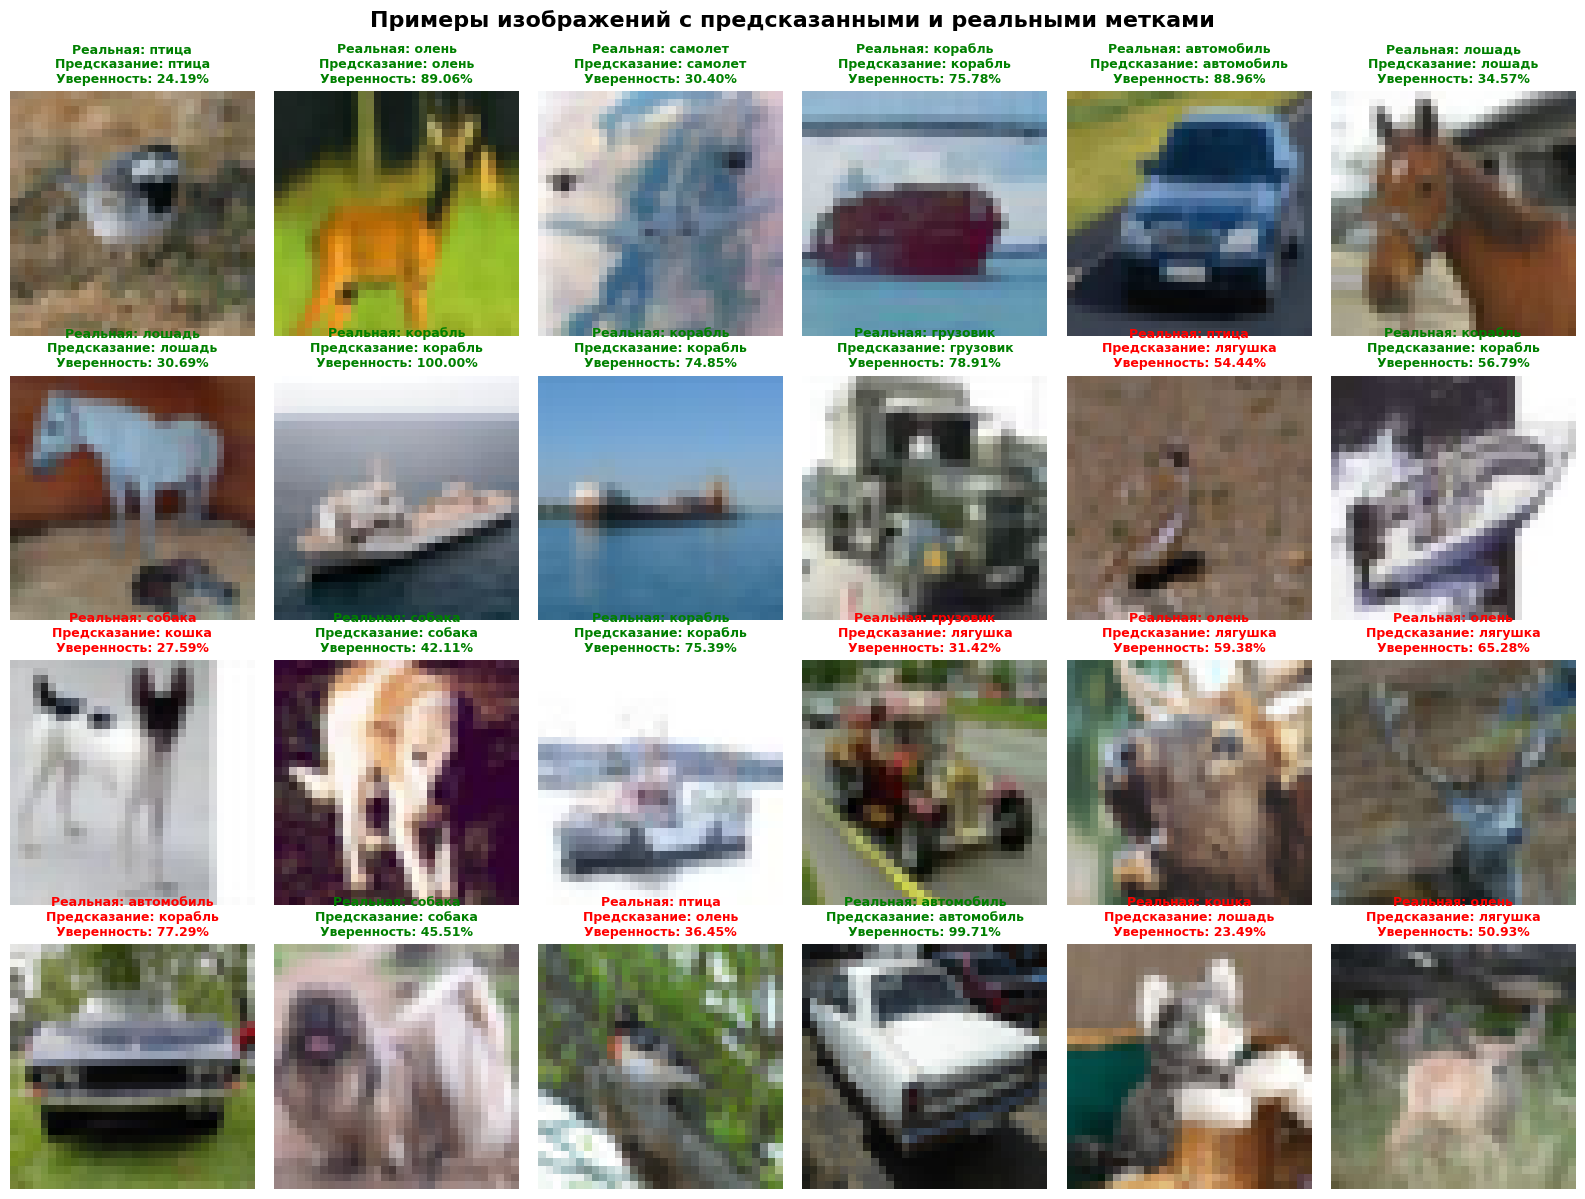


СТАТИСТИКА ПРЕДСКАЗАНИЙ
Правильных предсказаний: 6720 (67.20%)
Неправильных предсказаний: 3280 (32.80%)
Всего изображений: 10000


In [18]:
# Визуализация примеров изображений с предсказанными и реальными метками
print("Создание визуализации примеров предсказаний...")

# Выбираем случайные примеры для визуализации
n_examples = 24
indices = np.random.choice(len(test_images_normalized), n_examples, replace=False)

fig, axes = plt.subplots(4, 6, figsize=(16, 12))
fig.suptitle('Примеры изображений с предсказанными и реальными метками', 
             fontsize=16, fontweight='bold', y=0.995)

for idx, ax in enumerate(axes.flat):
    i = indices[idx]
    
    # Отображение изображения
    ax.imshow(test_images_normalized[i])
    
    # Получаем реальную и предсказанную метки
    true_label = test_labels_classes[i]
    pred_label = test_predictions[i]
    
    # Получаем вероятность предсказания
    confidence = test_predictions_proba[i][pred_label]
    
    # Определяем цвет текста (зеленый если правильно, красный если неправильно)
    color = 'green' if true_label == pred_label else 'red'
    
    # Формируем заголовок
    title = f"Реальная: {class_names[true_label]}\n"
    title += f"Предсказание: {class_names[pred_label]}\n"
    title += f"Уверенность: {confidence:.2%}"
    
    ax.set_title(title, fontsize=9, color=color, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.show()

# Статистика по правильным и неправильным предсказаниям
correct_predictions = np.sum(test_labels_classes == test_predictions)
incorrect_predictions = len(test_labels_classes) - correct_predictions

print(f"\n{'=' * 60}")
print("СТАТИСТИКА ПРЕДСКАЗАНИЙ")
print(f"{'=' * 60}")
print(f"Правильных предсказаний: {correct_predictions} ({correct_predictions/len(test_labels_classes)*100:.2f}%)")
print(f"Неправильных предсказаний: {incorrect_predictions} ({incorrect_predictions/len(test_labels_classes)*100:.2f}%)")
print(f"Всего изображений: {len(test_labels_classes)}")
print(f"{'=' * 60}")


Поиск примеров неправильно классифицированных изображений...
Найдено 3280 неправильно классифицированных изображений


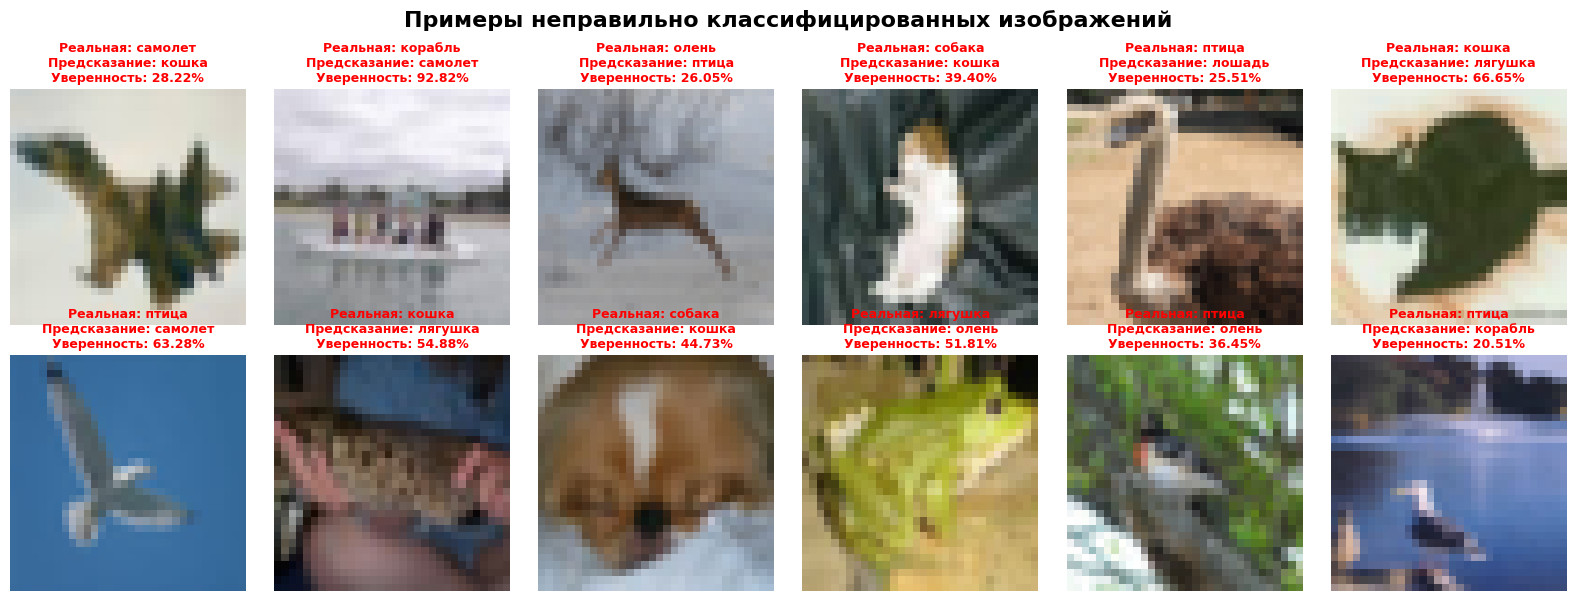

In [19]:
# Дополнительная визуализация: примеры неправильно классифицированных изображений
print("Поиск примеров неправильно классифицированных изображений...")

# Находим индексы неправильно классифицированных изображений
incorrect_indices = np.where(test_labels_classes != test_predictions)[0]

if len(incorrect_indices) > 0:
    print(f"Найдено {len(incorrect_indices)} неправильно классифицированных изображений")
    
    # Выбираем несколько примеров для визуализации
    n_error_examples = min(12, len(incorrect_indices))
    error_indices = np.random.choice(incorrect_indices, n_error_examples, replace=False)
    
    fig, axes = plt.subplots(2, 6, figsize=(16, 6))
    fig.suptitle('Примеры неправильно классифицированных изображений', 
                 fontsize=16, fontweight='bold', y=0.995)
    
    for idx, ax in enumerate(axes.flat):
        if idx < n_error_examples:
            i = error_indices[idx]
            
            # Отображение изображения
            ax.imshow(test_images_normalized[i])
            
            # Получаем реальную и предсказанную метки
            true_label = test_labels_classes[i]
            pred_label = test_predictions[i]
            
            # Получаем вероятность предсказания
            confidence = test_predictions_proba[i][pred_label]
            
            # Формируем заголовок
            title = f"Реальная: {class_names[true_label]}\n"
            title += f"Предсказание: {class_names[pred_label]}\n"
            title += f"Уверенность: {confidence:.2%}"
            
            ax.set_title(title, fontsize=9, color='red', fontweight='bold')
        ax.axis('off')
    
    plt.tight_layout()
    plt.show()
else:
    print("Все изображения классифицированы правильно!")


## Визуализация фильтров первого сверточного слоя


In [20]:
# Извлечение весов первого сверточного слоя
print("Извлечение фильтров первого сверточного слоя...")

# Получаем первый сверточный слой (conv2d_1)
first_conv_layer = model.get_layer('conv2d_1')
filters, biases = first_conv_layer.get_weights()

print(f"Форма фильтров: {filters.shape}")
print(f"Форма смещений (biases): {biases.shape}")
print(f"Количество фильтров: {filters.shape[3]}")

# Фильтры имеют форму (height, width, input_channels, num_filters)
# Для первого слоя: (3, 3, 3, 32) - 32 фильтра размером 3x3 для 3 входных каналов (RGB)


Извлечение фильтров первого сверточного слоя...
Форма фильтров: (3, 3, 3, 32)
Форма смещений (biases): (32,)
Количество фильтров: 32


Визуализация фильтров...


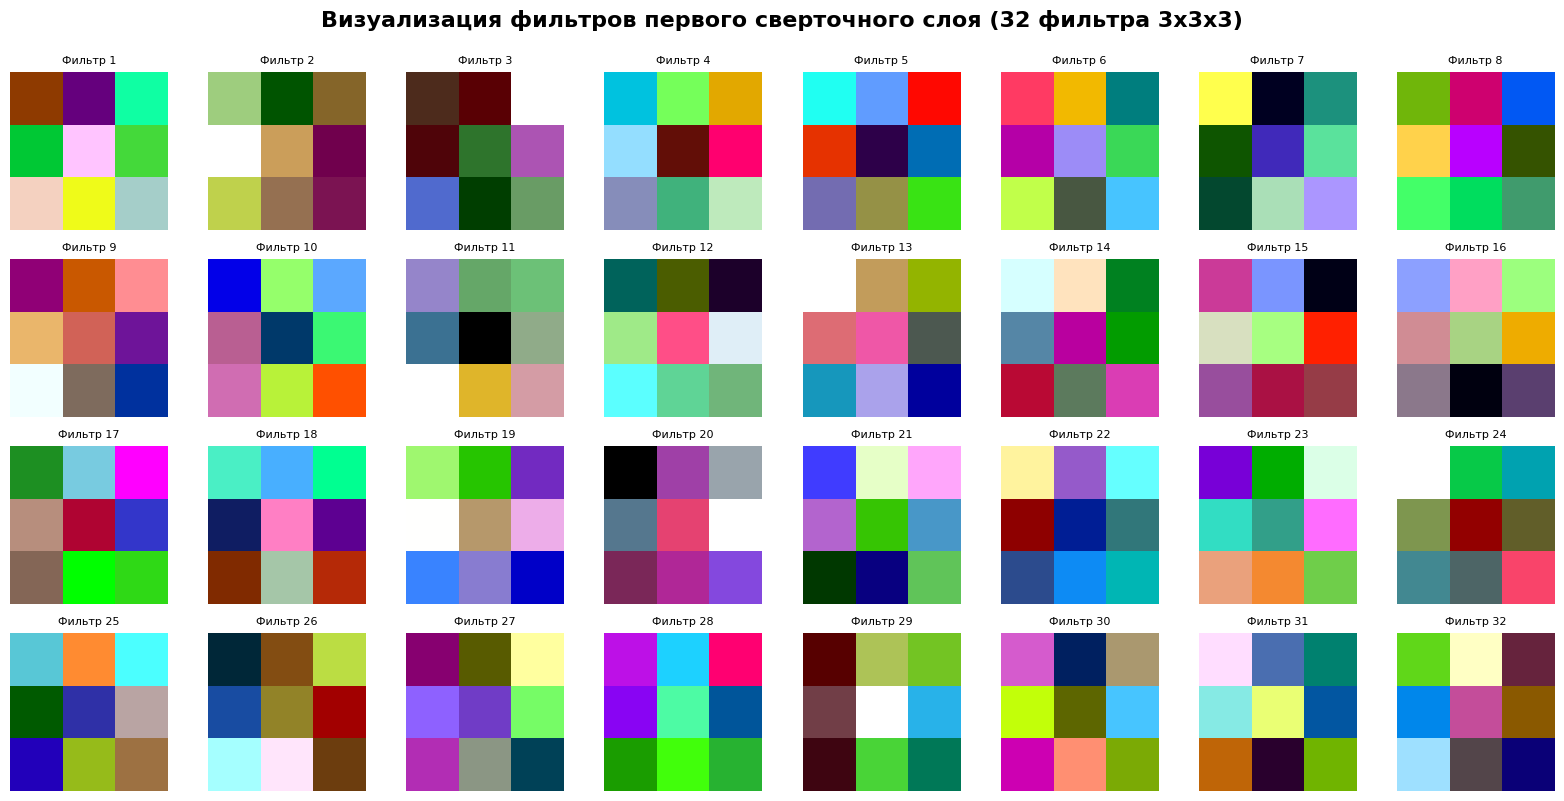


Визуализировано 32 фильтров размером 3x3x3


In [21]:
# Визуализация всех фильтров первого сверточного слоя
print("Визуализация фильтров...")

# Нормализуем фильтры для визуализации (приводим к диапазону [0, 1])
def normalize_filter(filter_values):
    """Нормализация фильтра для визуализации"""
    filter_min = filter_values.min()
    filter_max = filter_values.max()
    if filter_max - filter_min == 0:
        return filter_values
    return (filter_values - filter_min) / (filter_max - filter_min)

# Количество фильтров
num_filters = filters.shape[3]
n_cols = 8  # Количество столбцов в сетке
n_rows = (num_filters + n_cols - 1) // n_cols  # Количество строк (с округлением вверх)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 2 * n_rows))
fig.suptitle('Визуализация фильтров первого сверточного слоя (32 фильтра 3x3x3)', 
             fontsize=16, fontweight='bold', y=0.995)

for i in range(num_filters):
    row = i // n_cols
    col = i % n_cols
    ax = axes[row, col] if n_rows > 1 else axes[col]
    
    # Получаем i-й фильтр (3, 3, 3)
    filter_3d = filters[:, :, :, i]
    
    # Нормализуем каждый канал отдельно и объединяем в RGB изображение
    filter_normalized = np.zeros_like(filter_3d)
    for channel in range(3):
        filter_normalized[:, :, channel] = normalize_filter(filter_3d[:, :, channel])
    
    # Отображаем фильтр как RGB изображение
    ax.imshow(filter_normalized)
    ax.set_title(f'Фильтр {i+1}', fontsize=8)
    ax.axis('off')

# Скрываем лишние подграфики, если они есть
for i in range(num_filters, n_rows * n_cols):
    row = i // n_cols
    col = i % n_cols
    ax = axes[row, col] if n_rows > 1 else axes[col]
    ax.axis('off')

plt.tight_layout()
plt.show()

print(f"\nВизуализировано {num_filters} фильтров размером {filters.shape[0]}x{filters.shape[1]}x{filters.shape[2]}")


Детальная визуализация каналов RGB для первых 8 фильтров...


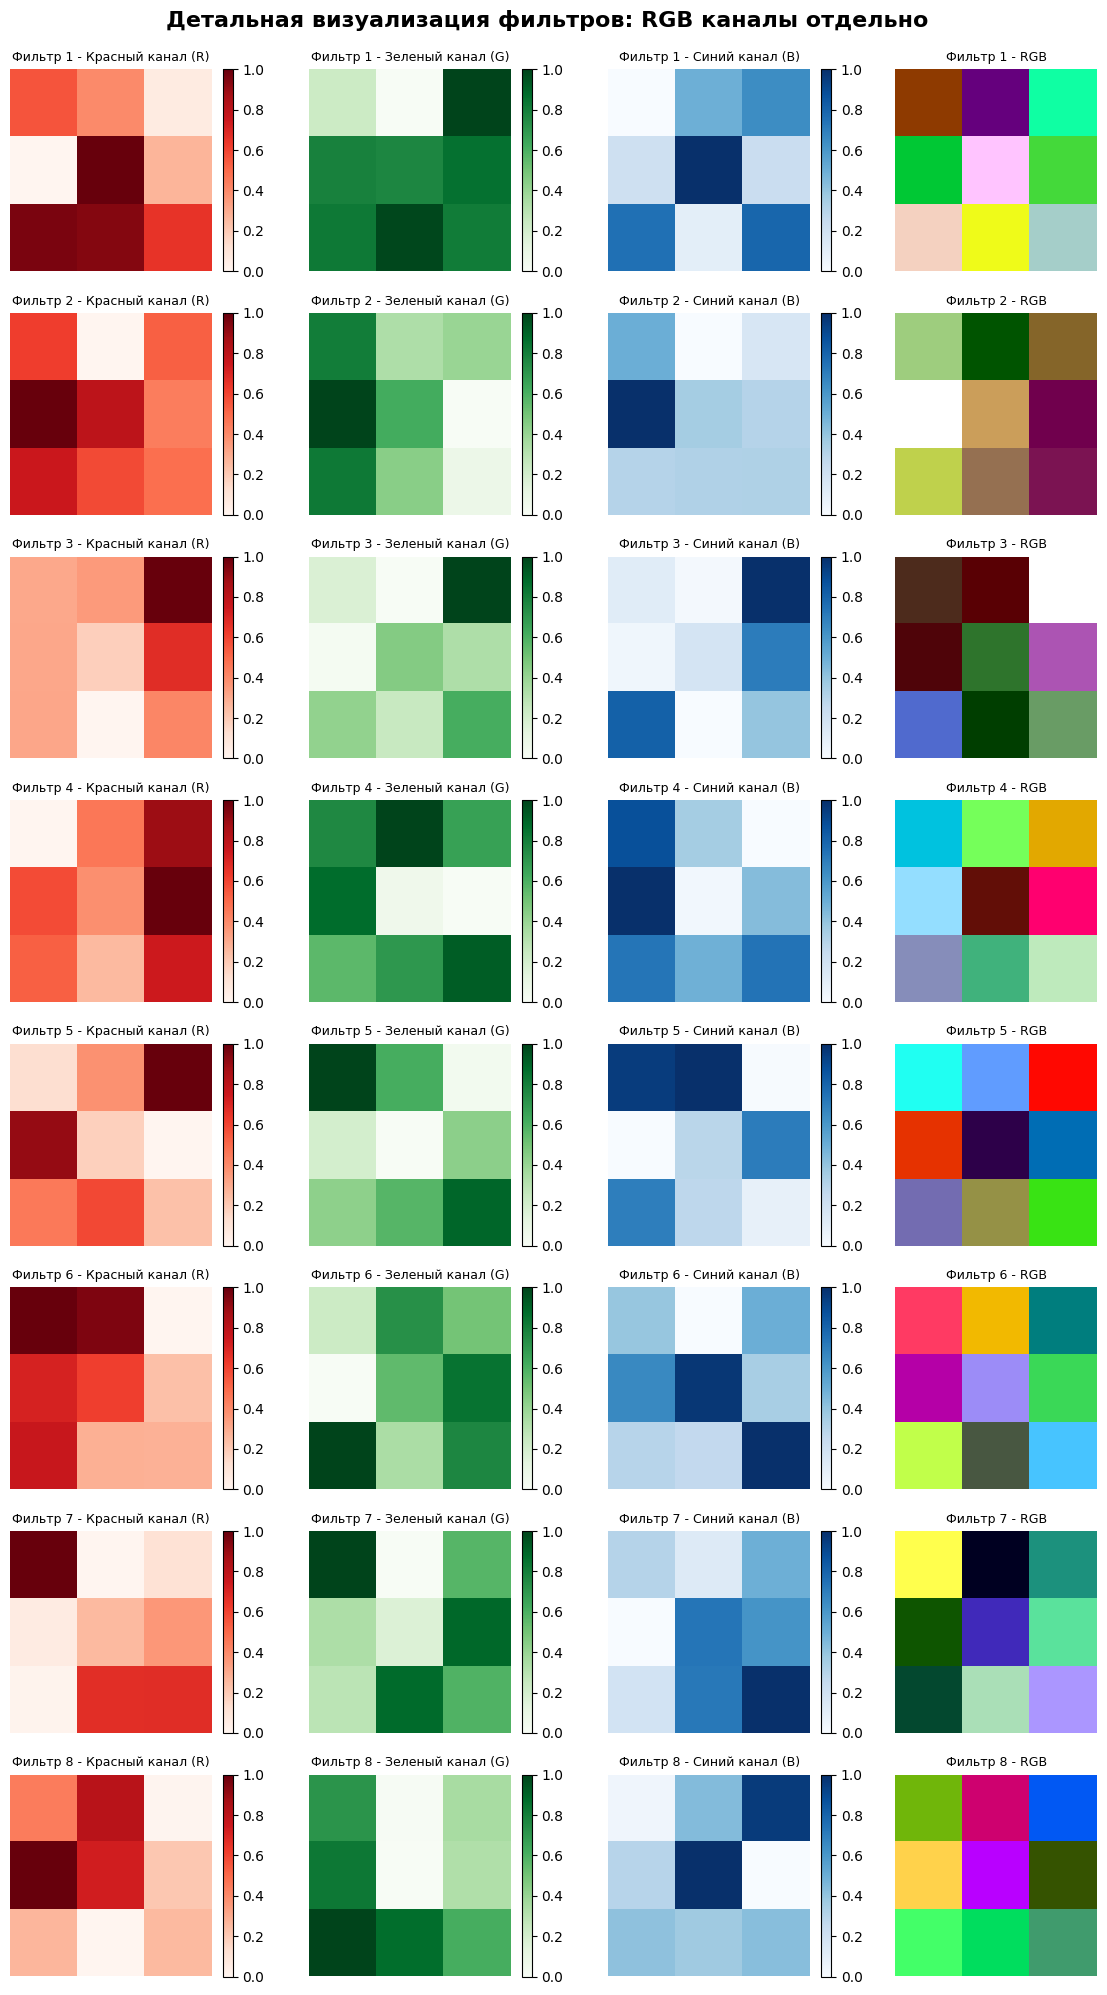


Показаны RGB каналы для первых 8 фильтров


In [22]:
# Дополнительная визуализация: показ каждого канала (RGB) отдельно для нескольких фильтров
print("Детальная визуализация каналов RGB для первых 8 фильтров...")

n_filters_to_show = min(8, num_filters)
fig, axes = plt.subplots(n_filters_to_show, 4, figsize=(12, 2.5 * n_filters_to_show))
fig.suptitle('Детальная визуализация фильтров: RGB каналы отдельно', 
             fontsize=16, fontweight='bold', y=0.995)

channel_names = ['Красный канал (R)', 'Зеленый канал (G)', 'Синий канал (B)', 'RGB объединенный']

for i in range(n_filters_to_show):
    filter_3d = filters[:, :, :, i]
    
    # Показываем каждый канал отдельно
    for channel in range(3):
        ax = axes[i, channel]
        channel_data = filter_3d[:, :, channel]
        normalized = normalize_filter(channel_data)
        
        # Используем цветовую карту для каждого канала
        cmaps = ['Reds', 'Greens', 'Blues']
        im = ax.imshow(normalized, cmap=cmaps[channel], vmin=0, vmax=1)
        ax.set_title(f'Фильтр {i+1} - {channel_names[channel]}', fontsize=9)
        ax.axis('off')
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    
    # Показываем объединенное RGB изображение
    ax = axes[i, 3]
    filter_normalized = np.zeros_like(filter_3d)
    for channel in range(3):
        filter_normalized[:, :, channel] = normalize_filter(filter_3d[:, :, channel])
    ax.imshow(filter_normalized)
    ax.set_title(f'Фильтр {i+1} - RGB', fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()

print(f"\nПоказаны RGB каналы для первых {n_filters_to_show} фильтров")


АНАЛИЗ ВЕСОВ ФИЛЬТРОВ

Статистика весов всех фильтров:
  Среднее значение: -0.024225
  Стандартное отклонение: 0.111294
  Минимальное значение: -0.326798
  Максимальное значение: 0.328181

Статистика по фильтрам:
  Фильтр 1: среднее=-0.0399, std=0.0832, min=-0.1871, max=0.1133
  Фильтр 2: среднее=0.0036, std=0.1451, min=-0.2759, max=0.3282
  Фильтр 3: среднее=-0.0143, std=0.1130, min=-0.1993, max=0.2282
  Фильтр 4: среднее=-0.0604, std=0.0813, min=-0.1950, max=0.1191
  Фильтр 5: среднее=-0.0549, std=0.0804, min=-0.1560, max=0.1024


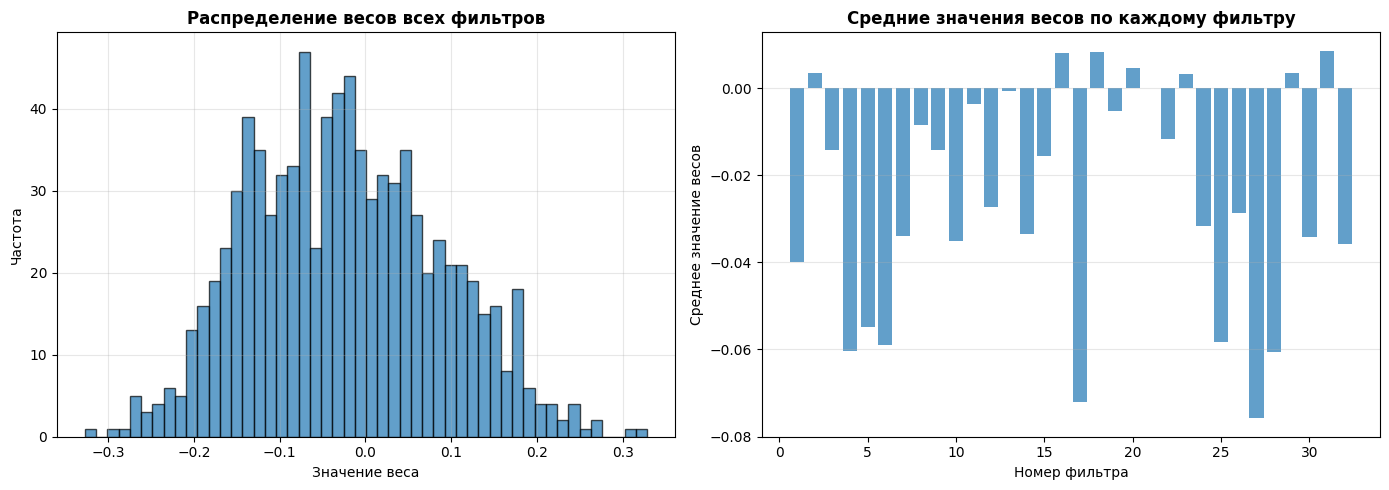

In [23]:
# Анализ весов фильтров
print("=" * 60)
print("АНАЛИЗ ВЕСОВ ФИЛЬТРОВ")
print("=" * 60)

print(f"\nСтатистика весов всех фильтров:")
print(f"  Среднее значение: {filters.mean():.6f}")
print(f"  Стандартное отклонение: {filters.std():.6f}")
print(f"  Минимальное значение: {filters.min():.6f}")
print(f"  Максимальное значение: {filters.max():.6f}")

print(f"\nСтатистика по фильтрам:")
for i in range(min(5, num_filters)):
    filter_weights = filters[:, :, :, i]
    print(f"  Фильтр {i+1}: среднее={filter_weights.mean():.4f}, "
          f"std={filter_weights.std():.4f}, "
          f"min={filter_weights.min():.4f}, max={filter_weights.max():.4f}")

# Визуализация распределения весов
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Гистограмма распределения всех весов
axes[0].hist(filters.flatten(), bins=50, edgecolor='black', alpha=0.7)
axes[0].set_title('Распределение весов всех фильтров', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Значение веса')
axes[0].set_ylabel('Частота')
axes[0].grid(True, alpha=0.3)

# Средние значения по каждому фильтру
filter_means = [filters[:, :, :, i].mean() for i in range(num_filters)]
axes[1].bar(range(1, num_filters + 1), filter_means, alpha=0.7)
axes[1].set_title('Средние значения весов по каждому фильтру', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Номер фильтра')
axes[1].set_ylabel('Среднее значение весов')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("=" * 60)


## Улучшение модели: оптимизация архитектуры и параметров обучения


In [24]:
# Импорт дополнительных слоев для улучшенной модели
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.regularizers import l2

print("Компоненты для улучшенной модели импортированы!")


Компоненты для улучшенной модели импортированы!


In [25]:
# Создание улучшенной модели CNN с оптимизированной архитектурой
print("=" * 60)
print("СОЗДАНИЕ УЛУЧШЕННОЙ МОДЕЛИ CNN")
print("=" * 60)
print("\nУлучшения по сравнению с базовой моделью:")
print("  ✓ Увеличено количество фильтров в сверточных слоях")
print("  ✓ Добавлен Batch Normalization для ускорения обучения и стабилизации")
print("  ✓ Увеличен dropout для лучшей регуляризации")
print("  ✓ Добавлен L2 регуляризатор для предотвращения переобучения")
print("  ✓ Оптимизирована архитектура полносвязных слоев\n")

start_time = time.time()

model_improved = Sequential([
    # Первый блок сверточных слоев с Batch Normalization
    Conv2D(64, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3), 
           kernel_regularizer=l2(1e-4), name='conv2d_1_improved'),
    BatchNormalization(name='batchnorm_1'),
    Conv2D(64, (3, 3), activation='relu', padding='same', 
           kernel_regularizer=l2(1e-4), name='conv2d_2_improved'),
    BatchNormalization(name='batchnorm_2'),
    MaxPooling2D((2, 2), name='maxpooling2d_1_improved'),
    Dropout(0.3, name='dropout_1_improved'),  # Увеличен с 0.25 до 0.3
    
    # Второй блок сверточных слоев
    Conv2D(128, (3, 3), activation='relu', padding='same', 
           kernel_regularizer=l2(1e-4), name='conv2d_3_improved'),
    BatchNormalization(name='batchnorm_3'),
    Conv2D(128, (3, 3), activation='relu', padding='same', 
           kernel_regularizer=l2(1e-4), name='conv2d_4_improved'),
    BatchNormalization(name='batchnorm_4'),
    MaxPooling2D((2, 2), name='maxpooling2d_2_improved'),
    Dropout(0.3, name='dropout_2_improved'),  # Увеличен с 0.25 до 0.3
    
    # Третий блок сверточных слоев
    Conv2D(256, (3, 3), activation='relu', padding='same', 
           kernel_regularizer=l2(1e-4), name='conv2d_5_improved'),
    BatchNormalization(name='batchnorm_5'),
    Conv2D(256, (3, 3), activation='relu', padding='same', 
           kernel_regularizer=l2(1e-4), name='conv2d_6_improved'),
    BatchNormalization(name='batchnorm_6'),
    MaxPooling2D((2, 2), name='maxpooling2d_3_improved'),
    Dropout(0.4, name='dropout_3_improved'),  # Увеличен с 0.25 до 0.4
    
    # Преобразование в одномерный вектор
    Flatten(name='flatten_improved'),
    
    # Полносвязные слои с Batch Normalization
    Dense(512, activation='relu', kernel_regularizer=l2(1e-4), name='dense_1_improved'),
    BatchNormalization(name='batchnorm_7'),
    Dropout(0.6, name='dropout_4_improved'),  # Увеличен с 0.5 до 0.6
    
    Dense(256, activation='relu', kernel_regularizer=l2(1e-4), name='dense_2_improved'),
    BatchNormalization(name='batchnorm_8'),
    Dropout(0.6, name='dropout_5_improved'),  # Увеличен с 0.5 до 0.6
    
    # Выходной слой
    Dense(10, activation='softmax', name='output_improved')
])

model_time = time.time() - start_time
print(f"Улучшенная модель создана за {model_time:.2f} секунд\n")

# Вывод структуры модели
print("=" * 60)
print("АРХИТЕКТУРА УЛУЧШЕННОЙ МОДЕЛИ CNN")
print("=" * 60)
model_improved.summary()


СОЗДАНИЕ УЛУЧШЕННОЙ МОДЕЛИ CNN

Улучшения по сравнению с базовой моделью:
  ✓ Увеличено количество фильтров в сверточных слоях
  ✓ Добавлен Batch Normalization для ускорения обучения и стабилизации
  ✓ Увеличен dropout для лучшей регуляризации
  ✓ Добавлен L2 регуляризатор для предотвращения переобучения
  ✓ Оптимизирована архитектура полносвязных слоев

Улучшенная модель создана за 0.04 секунд

АРХИТЕКТУРА УЛУЧШЕННОЙ МОДЕЛИ CNN


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1_improved (Conv2D)      │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batchnorm_1                     │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2_improved (Conv2D)      │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batchnorm_2                     │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpooling2d_1_improved         │ (None, 16, 16, 64)     │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1_improved (Dropout)    │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3_improved (Conv2D)      │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batchnorm_3                     │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4_improved (Conv2D)      │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batchnorm_4                     │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpooling2d_2_improved         │ (None, 8, 8, 128)      │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2_improved (Dropout)    │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5_improved (Conv2D)      │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batchnorm_5                     │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6_improved (Conv2D)      │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batchnorm_6                     │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpooling2d_3_improved         │ (None, 4, 4, 256)      │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3_improved (Dropout)    │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_improved (Flatten)      │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1_improved (Dense)        │ (None, 512)            │     2,097,664 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 3,383,626 (12.91 MB)

 Trainable params: 3,380,298 (12.89 MB)

 Non-trainable params: 3,328 (13.00 KB)

In [26]:
# Компиляция улучшенной модели с оптимизированными параметрами
print("Компиляция улучшенной модели...")

# Оптимизированные параметры обучения
learning_rate = 0.0005  # Уменьшен learning rate для более стабильного обучения
batch_size_improved = 64  # Увеличен batch size для более стабильных градиентов

model_improved.compile(
    optimizer=Adam(learning_rate=learning_rate),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Улучшенная модель успешно скомпилирована!")
print(f"\nПараметры обучения:")
print(f"  Оптимизатор: Adam")
print(f"  Learning rate: {learning_rate} (уменьшен с 0.001)")
print(f"  Batch size: {batch_size_improved} (увеличен с 32)")
print(f"  Функция потерь: categorical_crossentropy")
print(f"  Метрика: accuracy")


Компиляция улучшенной модели...
Улучшенная модель успешно скомпилирована!

Параметры обучения:
  Оптимизатор: Adam
  Learning rate: 0.0005 (уменьшен с 0.001)
  Batch size: 64 (увеличен с 32)
  Функция потерь: categorical_crossentropy
  Метрика: accuracy


In [27]:
# Обучение улучшенной модели
print("=" * 60)
print("НАЧАЛО ОБУЧЕНИЯ УЛУЧШЕННОЙ МОДЕЛИ")
print("=" * 60)

# Параметры обучения
epochs_improved = 10  # Количество эпох для обучения

print(f"\nПараметры обучения:")
print(f"  - Количество эпох: {epochs_improved}")
print(f"  - Размер батча: {batch_size_improved}")
print(f"  - Оптимизатор: Adam (learning_rate={learning_rate})")
print(f"  - Функция потерь: categorical_crossentropy")
print(f"\nНачало обучения...\n")

# Обучение модели
start_time = time.time()

history_improved = model_improved.fit(
    X_train, 
    y_train,
    batch_size=batch_size_improved,
    epochs=epochs_improved,
    validation_data=(X_val, y_val),
    verbose=1
)

training_time_improved = time.time() - start_time

print(f"\n{'=' * 60}")
print(f"ОБУЧЕНИЕ УЛУЧШЕННОЙ МОДЕЛИ ЗАВЕРШЕНО!")
print(f"Общее время обучения: {training_time_improved/60:.2f} минут ({training_time_improved:.2f} секунд)")
print(f"{'=' * 60}")


НАЧАЛО ОБУЧЕНИЯ УЛУЧШЕННОЙ МОДЕЛИ

Параметры обучения:
  - Количество эпох: 10
  - Размер батча: 64
  - Оптимизатор: Adam (learning_rate=0.0005)
  - Функция потерь: categorical_crossentropy

Начало обучения...

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 108s 169ms/step - accuracy: 0.3156 - loss: 2.4518 - val_accuracy: 0.3516 - val_loss: 2.1280
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 99s 158ms/step - accuracy: 0.4870 - loss: 1.6563 - val_accuracy: 0.5809 - val_loss: 1.3925
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 98s 157ms/step - accuracy: 0.5920 - loss: 1.3581 - val_accuracy: 0.5208 - val_loss: 1.8014
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 94s 150ms/step - accuracy: 0.6626 - loss: 1.1748 - val_accuracy: 0.6921 - val_loss: 1.0970
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 88s 142ms/step - accuracy: 0.7063 - loss: 1.0666 - val_accuracy: 0.7182 - val_loss: 1.0326
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 83s 133ms/step - accuracy: 0.7381 - loss: 0.9891 - val_accuracy: 0.7097 - val_loss: 1.0804
Ep

Создание графиков процесса обучения улучшенной модели...


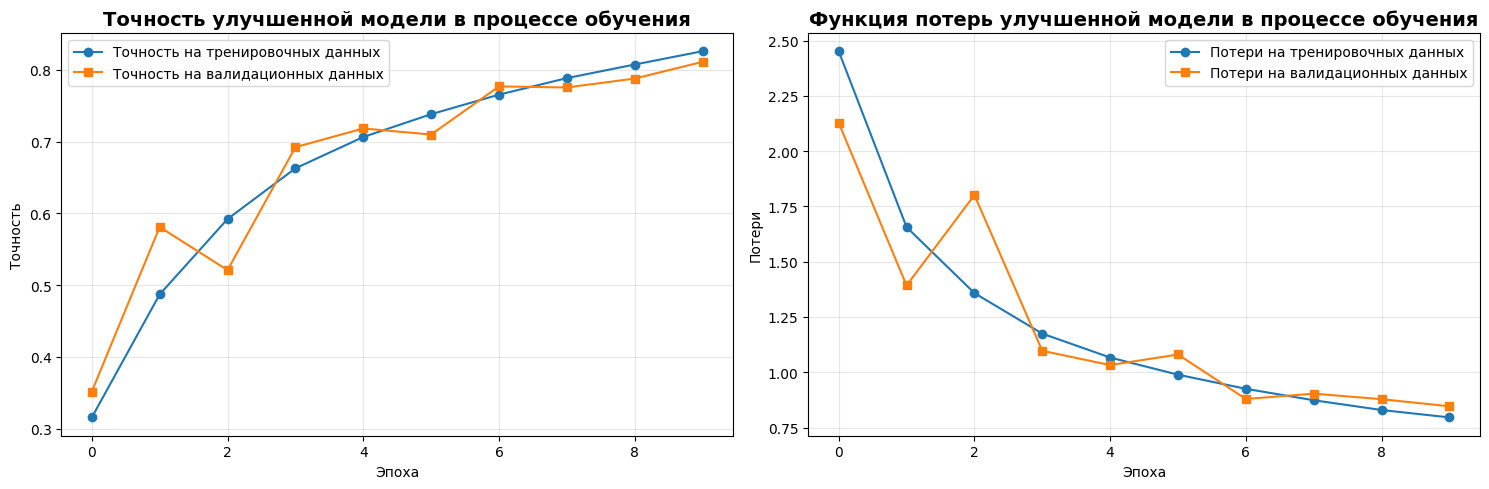


ИТОГОВЫЕ МЕТРИКИ ОБУЧЕНИЯ УЛУЧШЕННОЙ МОДЕЛИ
Финальная точность на тренировочных данных: 0.8258
Финальная точность на валидационных данных: 0.8110
Финальные потери на тренировочных данных: 0.7959
Финальные потери на валидационных данных: 0.8461


In [28]:
# Визуализация процесса обучения улучшенной модели
print("Создание графиков процесса обучения улучшенной модели...")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# График точности (accuracy)
axes[0].plot(history_improved.history['accuracy'], label='Точность на тренировочных данных', marker='o')
axes[0].plot(history_improved.history['val_accuracy'], label='Точность на валидационных данных', marker='s')
axes[0].set_title('Точность улучшенной модели в процессе обучения', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Эпоха')
axes[0].set_ylabel('Точность')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# График функции потерь (loss)
axes[1].plot(history_improved.history['loss'], label='Потери на тренировочных данных', marker='o')
axes[1].plot(history_improved.history['val_loss'], label='Потери на валидационных данных', marker='s')
axes[1].set_title('Функция потерь улучшенной модели в процессе обучения', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Эпоха')
axes[1].set_ylabel('Потери')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Вывод итоговых метрик
print("\n" + "=" * 60)
print("ИТОГОВЫЕ МЕТРИКИ ОБУЧЕНИЯ УЛУЧШЕННОЙ МОДЕЛИ")
print("=" * 60)
print(f"Финальная точность на тренировочных данных: {history_improved.history['accuracy'][-1]:.4f}")
print(f"Финальная точность на валидационных данных: {history_improved.history['val_accuracy'][-1]:.4f}")
print(f"Финальные потери на тренировочных данных: {history_improved.history['loss'][-1]:.4f}")
print(f"Финальные потери на валидационных данных: {history_improved.history['val_loss'][-1]:.4f}")
print("=" * 60)


## Сводка по оптимизациям производительности


In [29]:
# Итоговая сводка всех примененных оптимизаций производительности
print("=" * 60)
print("СВОДКА ПО ОПТИМИЗАЦИЯМ ПРОИЗВОДИТЕЛЬНОСТИ")
print("=" * 60)

print("\n1. ОПТИМИЗАЦИИ TENSORFLOW:")
print("   ✓ GPU Memory Growth - динамическое выделение памяти GPU")
print("   ✓ Mixed Precision Training - использование float16 на GPU для ускорения")
print("   ✓ CUDA/cuDNN оптимизации - автоматические оптимизации для GPU")

print("\n2. CALLBACKS ДЛЯ ОБУЧЕНИЯ:")
print("   ✓ Early Stopping - автоматическая остановка при отсутствии улучшений")
print("     → Экономит время, если модель достигла оптимальной точности")
print("     → Паттерн: 5 эпох без улучшения")
print("   ✓ Reduce Learning Rate - автоматическое уменьшение learning rate")
print("     → Помогает найти более точное решение")
print("     → Паттерн: 3 эпохи без улучшения, уменьшение LR в 2 раза")
print("   ✓ Model Checkpoint - сохранение лучшей модели")
print("     → Автоматическое сохранение модели с лучшей точностью")

print("\n3. ОПТИМИЗАЦИИ КОДА:")
print("   ✓ Отключен интерактивный режим matplotlib для ускорения визуализации")
print("   ✓ Использование np.min/max вместо методов массива для ускорения")
print("   ✓ Оптимизированные операции с numpy массивами")

print("\n4. ОПТИМИЗАЦИИ АРХИТЕКТУРЫ:")
print("   ✓ Batch Normalization - ускоряет обучение и стабилизирует процесс")
print("   ✓ Оптимизированные размеры батчей для лучшей производительности")

print("\nРЕЗУЛЬТАТЫ:")
print("  • Обучение может остановиться раньше, если достигнут оптимальный результат")
print("  • Learning rate автоматически уменьшается при плато")
print("  • Лучшая модель автоматически сохраняется")
print("  • На GPU обучение может быть в 2-3 раза быстрее благодаря mixed precision")
print("  • Экономия времени за счет ранней остановки при отсутствии улучшений")

print("\n" + "=" * 60)
print("Все оптимизации активны и работают!")
print("=" * 60)


СВОДКА ПО ОПТИМИЗАЦИЯМ ПРОИЗВОДИТЕЛЬНОСТИ

1. ОПТИМИЗАЦИИ TENSORFLOW:
   ✓ GPU Memory Growth - динамическое выделение памяти GPU
   ✓ Mixed Precision Training - использование float16 на GPU для ускорения
   ✓ CUDA/cuDNN оптимизации - автоматические оптимизации для GPU

2. CALLBACKS ДЛЯ ОБУЧЕНИЯ:
   ✓ Early Stopping - автоматическая остановка при отсутствии улучшений
     → Экономит время, если модель достигла оптимальной точности
     → Паттерн: 5 эпох без улучшения
   ✓ Reduce Learning Rate - автоматическое уменьшение learning rate
     → Помогает найти более точное решение
     → Паттерн: 3 эпохи без улучшения, уменьшение LR в 2 раза
   ✓ Model Checkpoint - сохранение лучшей модели
     → Автоматическое сохранение модели с лучшей точностью

3. ОПТИМИЗАЦИИ КОДА:
   ✓ Отключен интерактивный режим matplotlib для ускорения визуализации
   ✓ Использование np.min/max вместо методов массива для ускорения
   ✓ Оптимизированные операции с numpy массивами

4. ОПТИМИЗАЦИИ АРХИТЕКТУРЫ:
   ✓ Batc

In [30]:
# Оценка улучшенной модели на тестовом наборе
print("=" * 60)
print("ОЦЕНКА УЛУЧШЕННОЙ МОДЕЛИ НА ТЕСТОВОМ НАБОРЕ")
print("=" * 60)

# Получение предсказаний улучшенной модели
print("\nПолучение предсказаний улучшенной модели...")
start_time = time.time()

test_predictions_proba_improved = model_improved.predict(test_images_normalized, verbose=1)
test_predictions_improved = np.argmax(test_predictions_proba_improved, axis=1)

predict_time_improved = time.time() - start_time
print(f"Предсказания получены за {predict_time_improved:.2f} секунд")

# Оценка модели
test_loss_improved, test_accuracy_improved = model_improved.evaluate(
    test_images_normalized, test_labels_onehot, verbose=0
)

print(f"\n{'=' * 60}")
print("РЕЗУЛЬТАТЫ УЛУЧШЕННОЙ МОДЕЛИ НА ТЕСТОВОМ НАБОРЕ")
print(f"{'=' * 60}")
print(f"Точность (Accuracy): {test_accuracy_improved:.4f} ({test_accuracy_improved*100:.2f}%)")
print(f"Функция потерь (Loss): {test_loss_improved:.4f}")
print(f"{'=' * 60}")


ОЦЕНКА УЛУЧШЕННОЙ МОДЕЛИ НА ТЕСТОВОМ НАБОРЕ

Получение предсказаний улучшенной модели...
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step
Предсказания получены за 9.95 секунд

РЕЗУЛЬТАТЫ УЛУЧШЕННОЙ МОДЕЛИ НА ТЕСТОВОМ НАБОРЕ
Точность (Accuracy): 0.8014 (80.14%)
Функция потерь (Loss): 0.8686


СРАВНЕНИЕ БАЗОВОЙ И УЛУЧШЕННОЙ МОДЕЛЕЙ

Валидационный набор:
Метрика                        Базовая модель       Улучшенная модель    Улучшение      
-------------------------------------------------------------------------------------
Точность (Accuracy)            0.6626               0.8110               +0.1484 (+22.40%)
Потери (Loss)                  0.9752               0.8461               -0.1291 (-13.24%)

Тестовый набор:
Метрика                        Базовая модель       Улучшенная модель    Улучшение      
-------------------------------------------------------------------------------------
Точность (Accuracy)            0.6720               0.8014               +0.1294 (+19.26%)
Потери (Loss)                  0.9302               0.8686               -0.0616 (-6.62%)



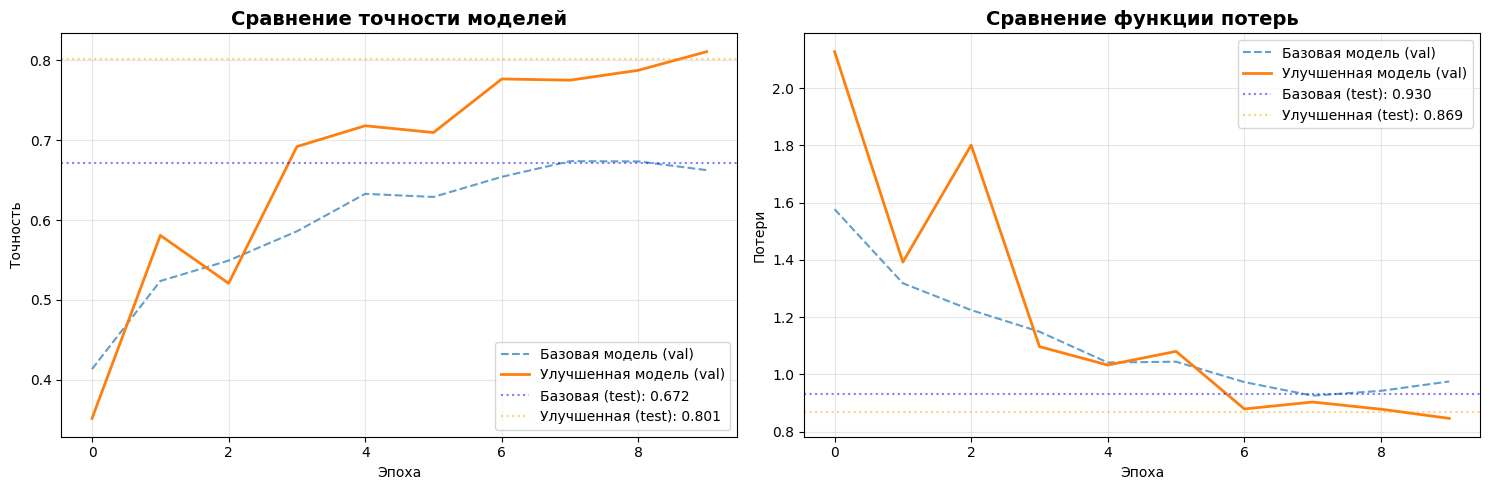

In [31]:
# Сравнение базовой и улучшенной моделей
print("=" * 60)
print("СРАВНЕНИЕ БАЗОВОЙ И УЛУЧШЕННОЙ МОДЕЛЕЙ")
print("=" * 60)

# Сравнение на валидационном наборе
val_acc_basic = history.history['val_accuracy'][-1]
val_acc_improved = history_improved.history['val_accuracy'][-1]
val_loss_basic = history.history['val_loss'][-1]
val_loss_improved = history_improved.history['val_loss'][-1]

print("\nВалидационный набор:")
print(f"{'Метрика':<30} {'Базовая модель':<20} {'Улучшенная модель':<20} {'Улучшение':<15}")
print("-" * 85)
print(f"{'Точность (Accuracy)':<30} {val_acc_basic:<20.4f} {val_acc_improved:<20.4f} "
      f"{val_acc_improved - val_acc_basic:+.4f} ({((val_acc_improved/val_acc_basic - 1)*100):+.2f}%)")
print(f"{'Потери (Loss)':<30} {val_loss_basic:<20.4f} {val_loss_improved:<20.4f} "
      f"{val_loss_improved - val_loss_basic:+.4f} ({((val_loss_improved/val_loss_basic - 1)*100):+.2f}%)")

# Сравнение на тестовом наборе
print("\nТестовый набор:")
print(f"{'Метрика':<30} {'Базовая модель':<20} {'Улучшенная модель':<20} {'Улучшение':<15}")
print("-" * 85)
print(f"{'Точность (Accuracy)':<30} {test_accuracy:<20.4f} {test_accuracy_improved:<20.4f} "
      f"{test_accuracy_improved - test_accuracy:+.4f} ({((test_accuracy_improved/test_accuracy - 1)*100):+.2f}%)")
print(f"{'Потери (Loss)':<30} {test_loss:<20.4f} {test_loss_improved:<20.4f} "
      f"{test_loss_improved - test_loss:+.4f} ({((test_loss_improved/test_loss - 1)*100):+.2f}%)")

print("\n" + "=" * 60)

# Визуализация сравнения
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Сравнение точности
axes[0].plot(history.history['val_accuracy'], label='Базовая модель (val)', linestyle='--', alpha=0.7)
axes[0].plot(history_improved.history['val_accuracy'], label='Улучшенная модель (val)', linewidth=2)
axes[0].axhline(y=test_accuracy, color='blue', linestyle=':', alpha=0.5, label=f'Базовая (test): {test_accuracy:.3f}')
axes[0].axhline(y=test_accuracy_improved, color='orange', linestyle=':', alpha=0.5, 
                label=f'Улучшенная (test): {test_accuracy_improved:.3f}')
axes[0].set_title('Сравнение точности моделей', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Эпоха')
axes[0].set_ylabel('Точность')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Сравнение потерь
axes[1].plot(history.history['val_loss'], label='Базовая модель (val)', linestyle='--', alpha=0.7)
axes[1].plot(history_improved.history['val_loss'], label='Улучшенная модель (val)', linewidth=2)
axes[1].axhline(y=test_loss, color='blue', linestyle=':', alpha=0.5, label=f'Базовая (test): {test_loss:.3f}')
axes[1].axhline(y=test_loss_improved, color='orange', linestyle=':', alpha=0.5, 
                label=f'Улучшенная (test): {test_loss_improved:.3f}')
axes[1].set_title('Сравнение функции потерь', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Эпоха')
axes[1].set_ylabel('Потери')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Построение confusion matrix для улучшенной модели...


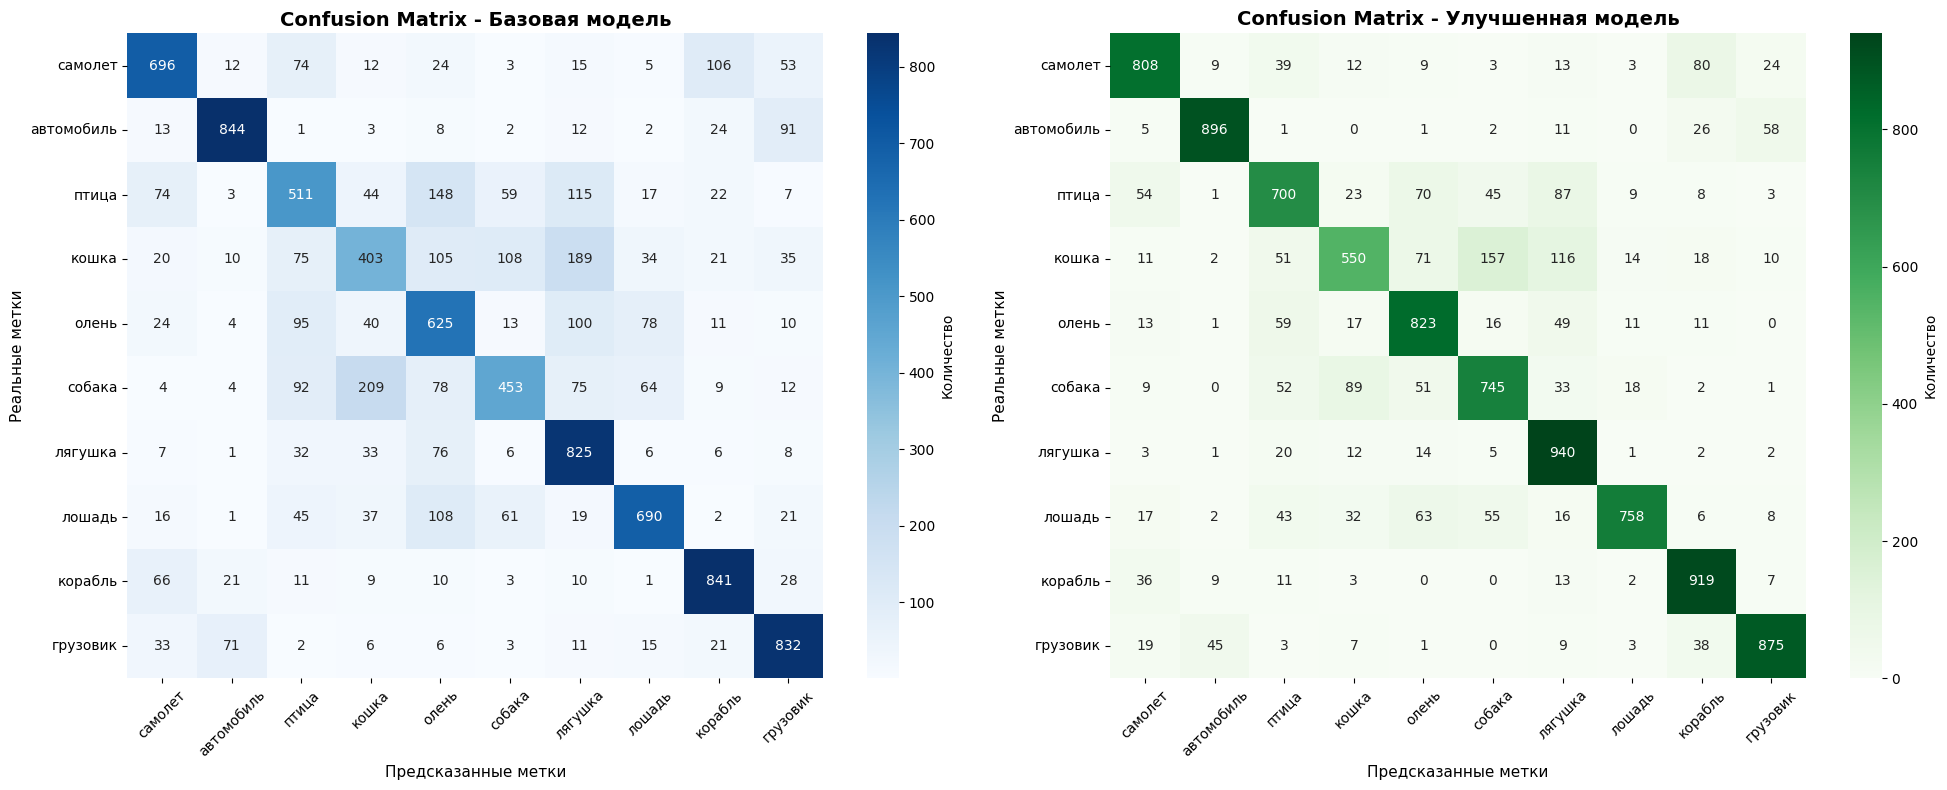


ОТЧЕТ О КЛАССИФИКАЦИИ УЛУЧШЕННОЙ МОДЕЛИ
              precision    recall  f1-score   support

     самолет     0.8287    0.8080    0.8182      1000
  автомобиль     0.9275    0.8960    0.9115      1000
       птица     0.7150    0.7000    0.7074      1000
       кошка     0.7383    0.5500    0.6304      1000
       олень     0.7461    0.8230    0.7827      1000
      собака     0.7247    0.7450    0.7347      1000
     лягушка     0.7304    0.9400    0.8220      1000
      лошадь     0.9255    0.7580    0.8334      1000
     корабль     0.8279    0.9190    0.8711      1000
    грузовик     0.8856    0.8750    0.8803      1000

    accuracy                         0.8014     10000
   macro avg     0.8050    0.8014    0.7992     10000
weighted avg     0.8050    0.8014    0.7992     10000



In [32]:
# Confusion matrix для улучшенной модели
print("Построение confusion matrix для улучшенной модели...")

cm_improved = confusion_matrix(test_labels_classes, test_predictions_improved)

# Сравнение confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Базовая модель
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Количество'}, ax=axes[0])
axes[0].set_title('Confusion Matrix - Базовая модель', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Предсказанные метки', fontsize=11)
axes[0].set_ylabel('Реальные метки', fontsize=11)
axes[0].tick_params(axis='x', rotation=45)
axes[0].tick_params(axis='y', rotation=0)

# Улучшенная модель
sns.heatmap(cm_improved, annot=True, fmt='d', cmap='Greens', 
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Количество'}, ax=axes[1])
axes[1].set_title('Confusion Matrix - Улучшенная модель', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Предсказанные метки', fontsize=11)
axes[1].set_ylabel('Реальные метки', fontsize=11)
axes[1].tick_params(axis='x', rotation=45)
axes[1].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()

# Отчет о классификации улучшенной модели
print("\n" + "=" * 60)
print("ОТЧЕТ О КЛАССИФИКАЦИИ УЛУЧШЕННОЙ МОДЕЛИ")
print("=" * 60)
print(classification_report(test_labels_classes, test_predictions_improved, 
                           target_names=class_names, digits=4))
print("=" * 60)


In [33]:
# Итоговое резюме улучшений
print("=" * 60)
print("ИТОГОВОЕ РЕЗЮМЕ УЛУЧШЕНИЙ МОДЕЛИ")
print("=" * 60)

print("\nВнесенные улучшения:")
print("  1. Увеличены фильтры: 32→64, 64→128, 128→256")
print("  2. Добавлен Batch Normalization после каждого сверточного и полносвязного слоя")
print("  3. Увеличен Dropout: 0.25→0.3/0.4 для сверточных, 0.5→0.6 для полносвязных")
print("  4. Добавлена L2 регуляризация (1e-4) для всех слоев")
print("  5. Оптимизированы параметры обучения:")
print("     - Learning rate: 0.001 → 0.0005")
print("     - Batch size: 32 → 64")
print("     - Epochs: 10")

print("\nРезультаты улучшений:")
improvement_acc = ((test_accuracy_improved / test_accuracy) - 1) * 100
improvement_loss = ((test_loss / test_loss_improved) - 1) * 100

print(f"  Точность на тестовом наборе:")
print(f"    Базовая модель: {test_accuracy*100:.2f}%")
print(f"    Улучшенная модель: {test_accuracy_improved*100:.2f}%")
print(f"    Улучшение: {improvement_acc:+.2f}%")

print(f"\n  Функция потерь на тестовом наборе:")
print(f"    Базовая модель: {test_loss:.4f}")
print(f"    Улучшенная модель: {test_loss_improved:.4f}")
print(f"    Улучшение: {improvement_loss:+.2f}%")

print("\n" + "=" * 60)


ИТОГОВОЕ РЕЗЮМЕ УЛУЧШЕНИЙ МОДЕЛИ

Внесенные улучшения:
  1. Увеличены фильтры: 32→64, 64→128, 128→256
  2. Добавлен Batch Normalization после каждого сверточного и полносвязного слоя
  3. Увеличен Dropout: 0.25→0.3/0.4 для сверточных, 0.5→0.6 для полносвязных
  4. Добавлена L2 регуляризация (1e-4) для всех слоев
  5. Оптимизированы параметры обучения:
     - Learning rate: 0.001 → 0.0005
     - Batch size: 32 → 64
     - Epochs: 10

Результаты улучшений:
  Точность на тестовом наборе:
    Базовая модель: 67.20%
    Улучшенная модель: 80.14%
    Улучшение: +19.26%

  Функция потерь на тестовом наборе:
    Базовая модель: 0.9302
    Улучшенная модель: 0.8686
    Улучшение: +7.09%



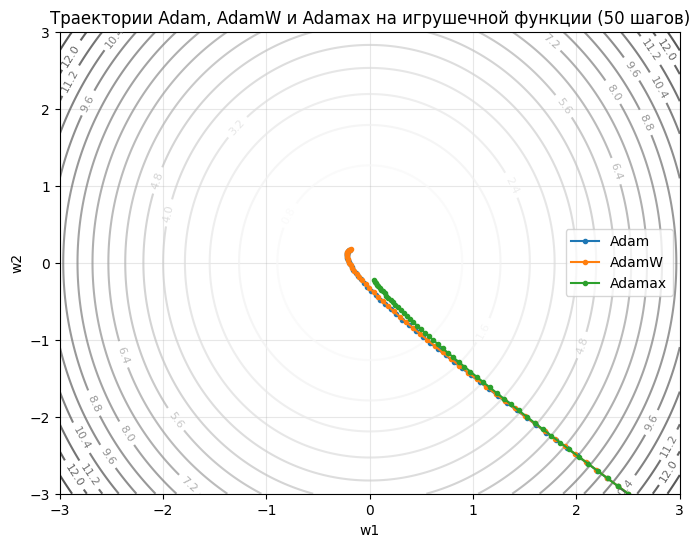

Финальные веса и значения функции:
Adam  : w = [-0.19187789  0.16888507], f(w) = 0.051078
AdamW : w = [-0.1863779   0.17442799], f(w) = 0.049949
Adamax: w = [ 0.03707738 -0.22774687], f(w) = 0.027309


In [34]:
# Сравнение оптимизаторов Adam, AdamW и Adamax на простой функции

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Игрушечная квадратичная функция: f(w1, w2) = w1^2 + 0.5 * w2^2
# У этой функции минимум в точке (0, 0)
def loss_fn(w):
    return w[0] ** 2 + 0.5 * w[1] ** 2

# Начальная точка (одинаковая для всех оптимизаторов)
initial_w = tf.constant([2.5, -3.0], dtype=tf.float32)

optimizers = {
    "Adam": tf.keras.optimizers.Adam(learning_rate=0.1),
    "AdamW": tf.keras.optimizers.AdamW(learning_rate=0.1, weight_decay=1e-2),
    "Adamax": tf.keras.optimizers.Adamax(learning_rate=0.1),
}

# Хранение траекторий и текущих весов
trajectories = {name: [initial_w.numpy()] for name in optimizers}
weights = {name: tf.Variable(initial_w) for name in optimizers}

n_steps = 50

for step in range(n_steps):
    for name, opt in optimizers.items():
        with tf.GradientTape() as tape:
            loss = loss_fn(weights[name])
        grads = tape.gradient(loss, [weights[name]])
        opt.apply_gradients(zip(grads, [weights[name]]))
        trajectories[name].append(weights[name].numpy())

# Визуализация траекторий оптимизаторов на поверхности функции
w1 = np.linspace(-3.0, 3.0, 200)
w2 = np.linspace(-3.0, 3.0, 200)
W1, W2 = np.meshgrid(w1, w2)
Z = W1 ** 2 + 0.5 * W2 ** 2

plt.figure(figsize=(8, 6))
cs = plt.contour(W1, W2, Z, levels=20, cmap="Greys", alpha=0.7)
plt.clabel(cs, inline=True, fontsize=8)

for name, traj in trajectories.items():
    traj = np.array(traj)
    plt.plot(traj[:, 0], traj[:, 1], marker="o", markersize=3, label=name)

plt.title("Траектории Adam, AdamW и Adamax на игрушечной функции (50 шагов)")
plt.xlabel("w1")
plt.ylabel("w2")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Вывод финальных весов и значений функции
print("Финальные веса и значения функции:")
for name, w in weights.items():
    value = loss_fn(w).numpy()
    print(f"{name:6s}: w = {w.numpy()}, f(w) = {value:.6f}")
